# 📊 Statistiques Descriptives & Persistance des Tendances
## SP500 | GOLD | BRENT | EURUSD — Données M5 (MetaTrader5 / Admirals)

Ce notebook réalise une analyse statistique complète des quatre actifs **et calibre la labélisation** pour un modèle de classification Up/Down :

1. Imports & Configuration
2. Fonctions statistiques (numpy)
3. Chargement & Audit des données
4. Prix de clôture — Vue d'ensemble
5. Log Returns — Statistiques descriptives
6. Distribution & Tests de normalité (Jarque-Bera)
7. Tests de stationnarité (ADF)
8. Autocorrélations (ACF / Ljung-Box)
9. Analyse de la Volatilité
10. Tail Risk (VaR / CVaR)
11. Corrélations statiques et dynamiques
12. **Analyse de Persistance des Tendances SP500 M5** ← nouveau
13. **Calibration de la Labélisation** ← nouveau
14. Tableau de synthèse & Conclusions

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from scipy import stats
from itertools import groupby

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')

COLORS = {
    'SP500':  '#2196F3',
    'GOLD':   '#FFC107',
    'BRENT':  '#4CAF50',
    'EURUSD': '#E91E63'
}

# ── Paramètres Broker Admirals (SP500 Cash CFD) ───────────────────────────
SPREAD_POINTS = 0.60   # spread typique en points d'indice
COMMISSION    = 0.00   # pas de commission
SPREAD_RT     = SPREAD_POINTS * 2  # coût aller-retour = 1.20 pts

print('✅ Imports OK')
print(f'   Spread aller-retour : {SPREAD_RT} pts (à couvrir pour être rentable)')

✅ Imports OK
   Spread aller-retour : 1.2 pts (à couvrir pour être rentable)


## 1. Fonctions statistiques (implémentées en numpy)

In [2]:
def compute_acf(series, nlags=40):
    s = np.asarray(series.dropna()) - np.mean(series.dropna())
    n, var = len(s), np.var(s)
    acf_vals = [1.0]
    for k in range(1, nlags + 1):
        cov_k = np.sum(s[:n-k] * s[k:]) / n
        acf_vals.append(cov_k / var)
    return np.array(acf_vals)

def ljung_box(series, lags):
    s = np.asarray(series.dropna())
    n = len(s)
    acf_v = compute_acf(series, nlags=lags)
    q = n * (n + 2) * np.sum(acf_v[1:lags+1]**2 / (n - np.arange(1, lags+1)))
    return q, 1 - stats.chi2.cdf(q, df=lags)

def jarque_bera(series):
    s = np.asarray(series.dropna())
    n = len(s)
    jb = n / 6 * (stats.skew(s)**2 + stats.kurtosis(s)**2 / 4)
    return jb, 1 - stats.chi2.cdf(jb, df=2)

def adf_test(series):
    s = np.asarray(series.dropna(), dtype=float)
    ds, y_lag = np.diff(s), s[:-1]
    X = np.column_stack([np.ones(len(y_lag)), y_lag])
    b, _, _, _ = np.linalg.lstsq(X, ds, rcond=None)
    resid = ds - X @ b
    s2 = np.sum(resid**2) / (len(ds) - 2)
    se = np.sqrt(np.diag(s2 * np.linalg.pinv(X.T @ X)))
    adf_stat = b[1] / se[1]
    cv = {'1%': -3.43, '5%': -2.86, '10%': -2.57}
    p = 0.01 if adf_stat < cv['1%'] else (0.05 if adf_stat < cv['5%'] else (0.10 if adf_stat < cv['10%'] else 0.99))
    return adf_stat, p, cv

print('✅ Fonctions statistiques chargées')

✅ Fonctions statistiques chargées


## 2. Chargement des données

In [3]:
DATA_DIR = Path('../SCR/data')

sp500  = pd.read_csv(DATA_DIR / 'sp500_m5.csv',  index_col='time', parse_dates=True)
gold   = pd.read_csv(DATA_DIR / 'or_m5.csv',     index_col='time', parse_dates=True)
brent  = pd.read_csv(DATA_DIR / 'brent_m5.csv',  index_col='time', parse_dates=True)
eurusd = pd.read_csv(DATA_DIR / 'eurusd_m5.csv', index_col='time', parse_dates=True)

datasets = {'SP500': sp500, 'GOLD': gold, 'BRENT': brent, 'EURUSD': eurusd}

print('✅ Données chargées')
sp500.head(5)

✅ Données chargées


,open,high,low,close,tick_volume
time,,,,,
2024-11-14 15:20:00+00:00,5995.33,5995.71,5994.22,5995.50,105
2024-11-14 15:25:00+00:00,5995.74,5996.00,5994.49,5995.73,100
2024-11-14 15:30:00+00:00,5995.48,5995.85,5985.72,5986.59,494
2024-11-14 15:35:00+00:00,5986.71,5988.46,5981.72,5985.08,404
2024-11-14 15:40:00+00:00,5985.45,5992.08,5985.44,5989.95,313


## 3. Audit de la qualité des données

In [4]:
# ── 3.1 Résumé général ───────────────────────────────────────────────────────
audit_rows = []
for name, df in datasets.items():
    audit_rows.append({
        'Actif': name, 'Bougies': len(df),
        'Début': df.index.min().strftime('%Y-%m-%d'),
        'Fin':   df.index.max().strftime('%Y-%m-%d'),
        'NaN (close)': df['close'].isna().sum(),
        'Doublons': df.index.duplicated().sum(),
    })
display(pd.DataFrame(audit_rows).set_index('Actif'))

,Bougies,Début,Fin,NaN (close),Doublons
Actif,,,,,
SP500,99999,2024-11-14,2026-04-17,0,0
GOLD,99999,2024-11-15,2026-04-17,0,0
BRENT,99999,2024-10-08,2026-04-17,0,0
EURUSD,99999,2024-12-11,2026-04-17,0,0


In [5]:
# ── 3.2 Gaps temporels (> 10 min, hors week-end) ─────────────────────────────
print('=== Gaps temporels > 10 min (hors week-end) ===')
for name, df in datasets.items():
    delta = df.index.to_series().diff().dt.total_seconds() / 60
    gaps  = delta[(delta > 10) & (delta < 2000)]
    print(f'  {name:8s}: {len(gaps):4d} gaps | max = {gaps.max():.0f} min')

=== Gaps temporels > 10 min (hors week-end) ===
  SP500   :  297 gaps | max = 1730 min
  GOLD    :  294 gaps | max = 1700 min
  BRENT   :  321 gaps | max = 1835 min
  EURUSD  :    4 gaps | max = 1510 min


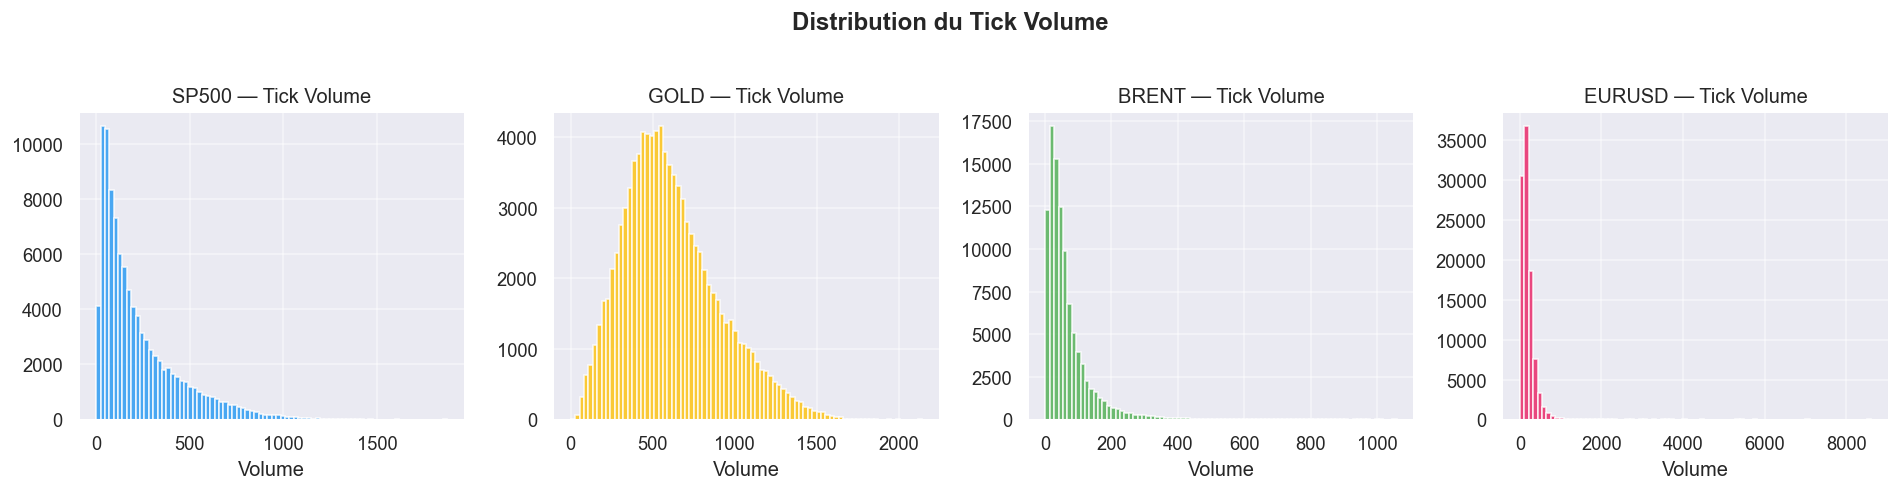

In [6]:
# ── 3.3 Distribution du tick_volume ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, df) in zip(axes, datasets.items()):
    ax.hist(df['tick_volume'], bins=80, color=COLORS[name], alpha=0.8, edgecolor='white')
    ax.set_title(f'{name} — Tick Volume')
    ax.set_xlabel('Volume')
plt.suptitle('Distribution du Tick Volume', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 4. Prix de clôture — Vue d'ensemble

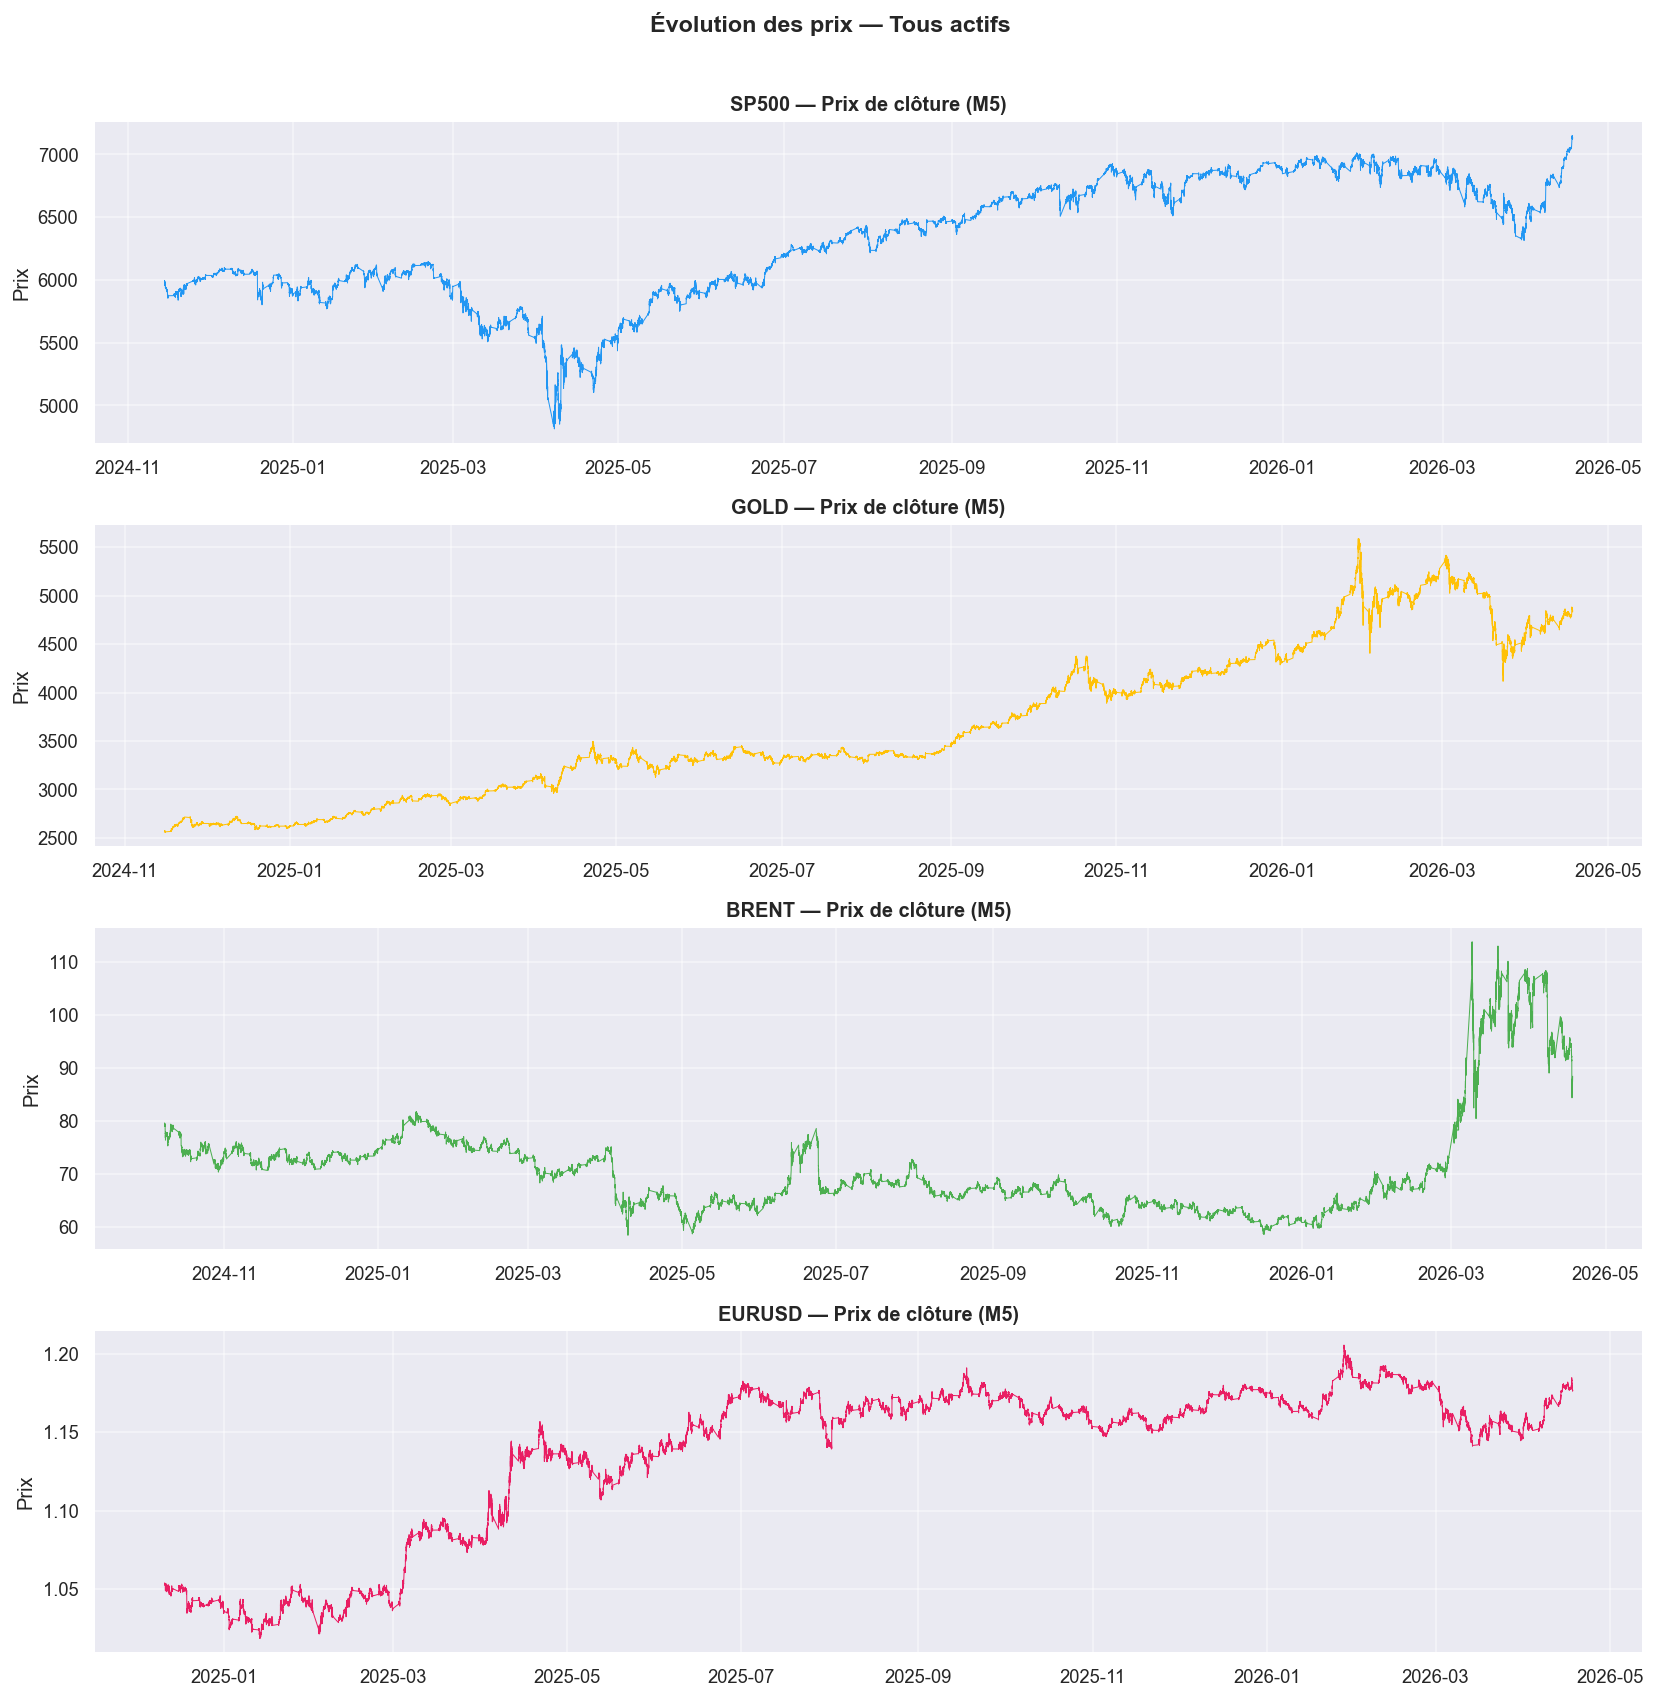

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
for ax, (name, df) in zip(axes, datasets.items()):
    ax.plot(df['close'], lw=0.6, color=COLORS[name])
    ax.set_title(f'{name} — Prix de clôture (M5)', fontweight='bold')
    ax.set_ylabel('Prix')
plt.suptitle('Évolution des prix — Tous actifs', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

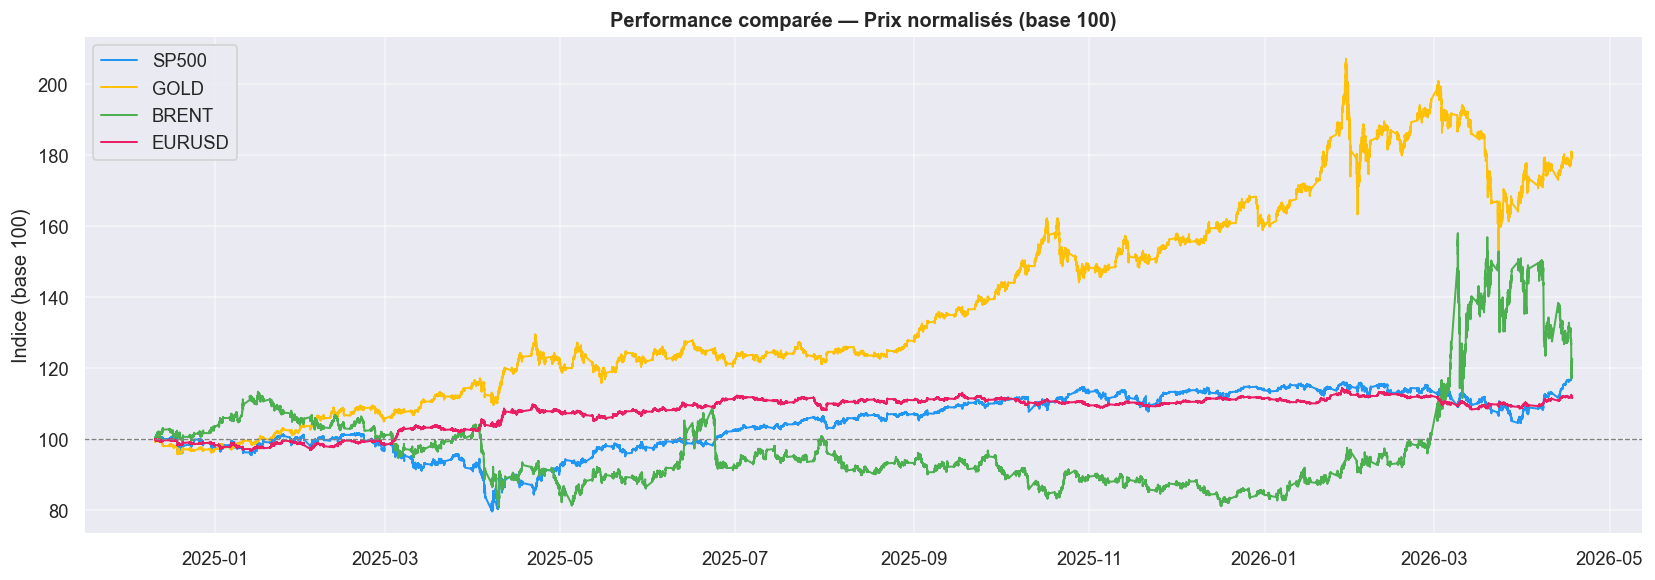

In [8]:
df_close  = pd.DataFrame({name: df['close'] for name, df in datasets.items()}).dropna()
prix_norm = df_close / df_close.iloc[0] * 100

plt.figure(figsize=(14, 5))
for name in prix_norm.columns:
    plt.plot(prix_norm[name], lw=1.2, label=name, color=COLORS[name])
plt.axhline(100, color='gray', lw=0.8, linestyle='--')
plt.title('Performance comparée — Prix normalisés (base 100)', fontweight='bold')
plt.ylabel('Indice (base 100)'); plt.legend(); plt.tight_layout(); plt.show()

## 5. Log Returns — Calcul et statistiques descriptives

In [9]:
for name, df in datasets.items():
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))

df_returns = pd.DataFrame(
    {name: df['log_return'] for name, df in datasets.items()}
).dropna()

print(f'✅ Log returns calculés. Shape : {df_returns.shape}')

✅ Log returns calculés. Shape : (87990, 4)


In [10]:
BOUGIES_PAR_AN = 252 * 78

rows = []
for name in df_returns.columns:
    r = df_returns[name].dropna()
    rows.append({
        'Actif': name,
        'Moyenne': round(r.mean(), 7), 'Médiane': round(r.median(), 7),
        'Std': round(r.std(), 6), 'Min': round(r.min(), 5), 'Max': round(r.max(), 5),
        'Skewness': round(r.skew(), 4), 'Kurtosis exc.': round(r.kurtosis(), 4),
        'Vol. Ann. (%)': round(r.std() * np.sqrt(BOUGIES_PAR_AN) * 100, 2),
    })
display(pd.DataFrame(rows).set_index('Actif'))

,Moyenne,Médiane,Std,Min,Max,Skewness,Kurtosis exc.,Vol. Ann. (%)
Actif,,,,,,,,
SP500,0.000002,0.000000,0.000716,-0.04268,0.03901,0.1884,385.5714,10.03
GOLD,0.000004,0.000011,0.000910,-0.02124,0.02847,-0.8237,48.4013,12.75
BRENT,0.000002,0.000000,0.001789,-0.14201,0.16062,2.5342,1447.1200,25.08
EURUSD,0.000001,0.000000,0.000307,-0.00787,0.01003,0.4252,51.7327,4.31


## 6. Distribution des rendements & Tests de normalité

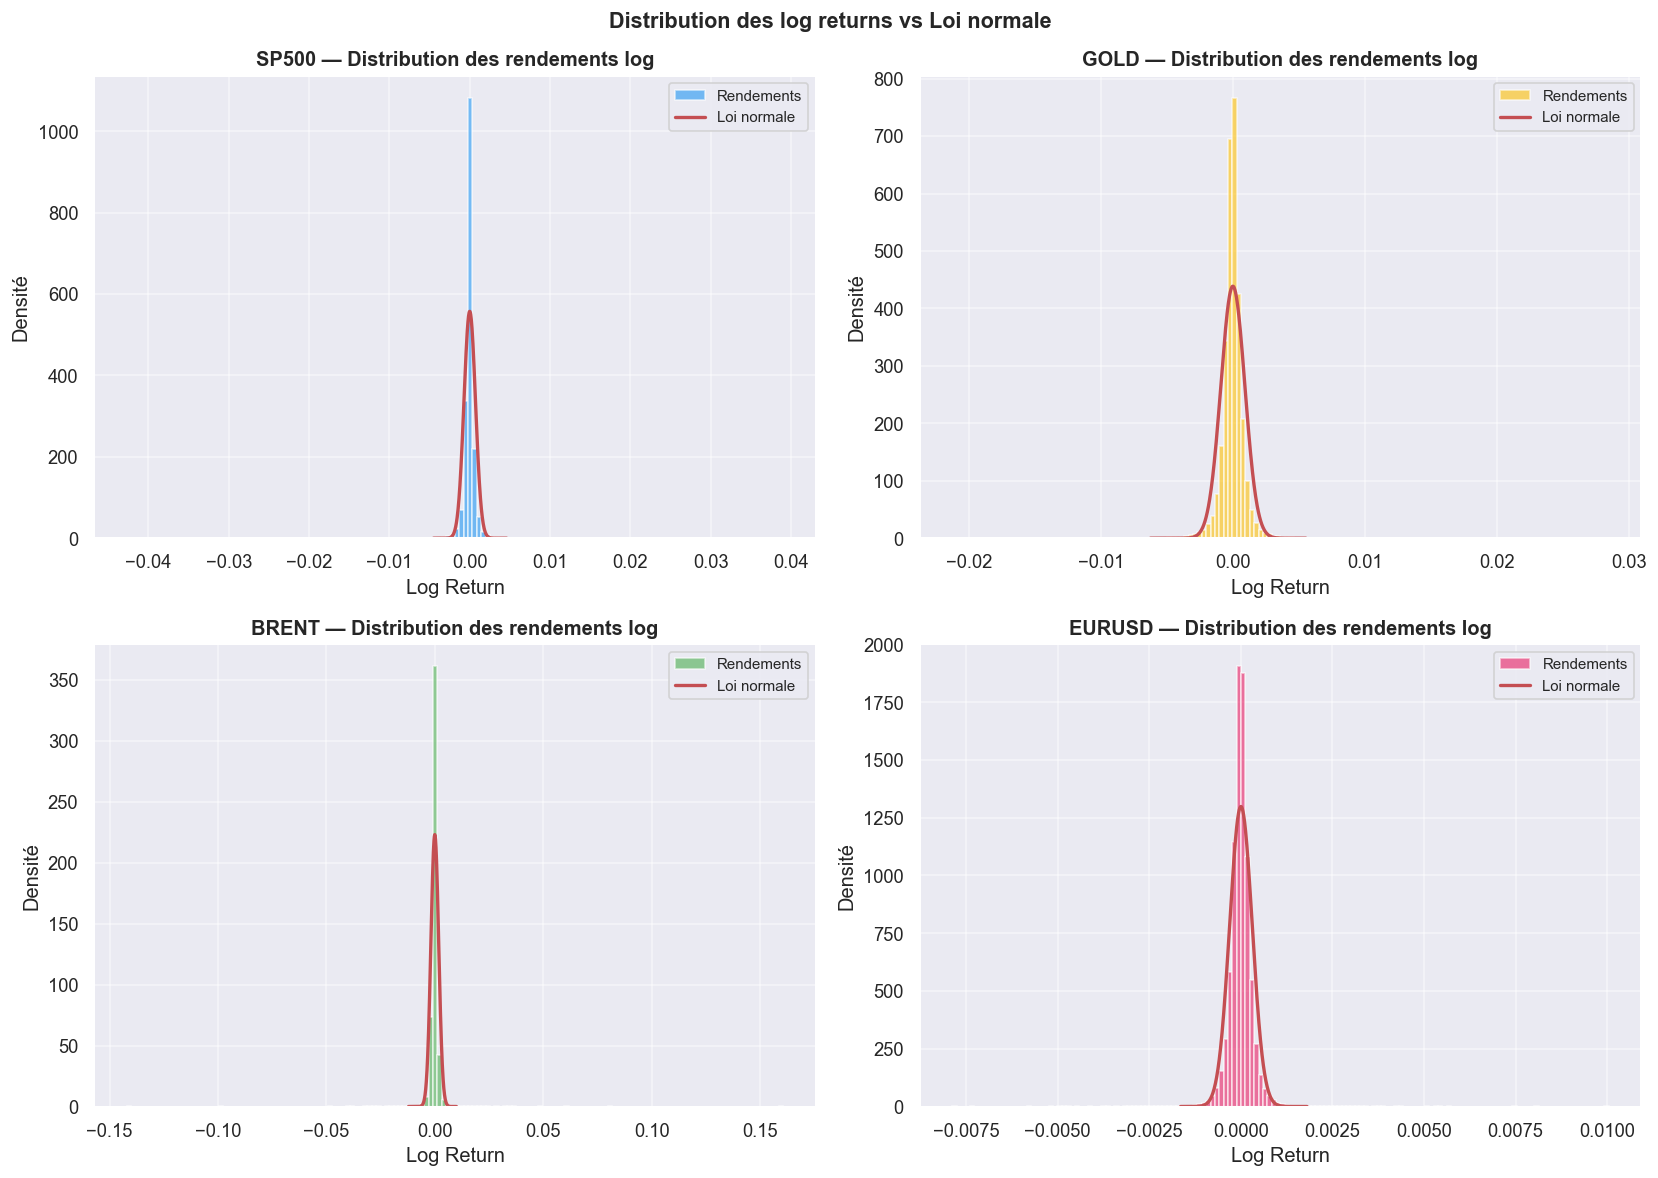

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, name in zip(axes, df_returns.columns):
    r = df_returns[name].dropna()
    ax.hist(r, bins=150, density=True, alpha=0.6, color=COLORS[name], label='Rendements')
    x = np.linspace(r.quantile(0.001), r.quantile(0.999), 400)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r-', lw=2, label='Loi normale')
    ax.set_title(f'{name} — Distribution des rendements log', fontweight='bold')
    ax.set_xlabel('Log Return'); ax.set_ylabel('Densité'); ax.legend(fontsize=9)
plt.suptitle('Distribution des log returns vs Loi normale', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

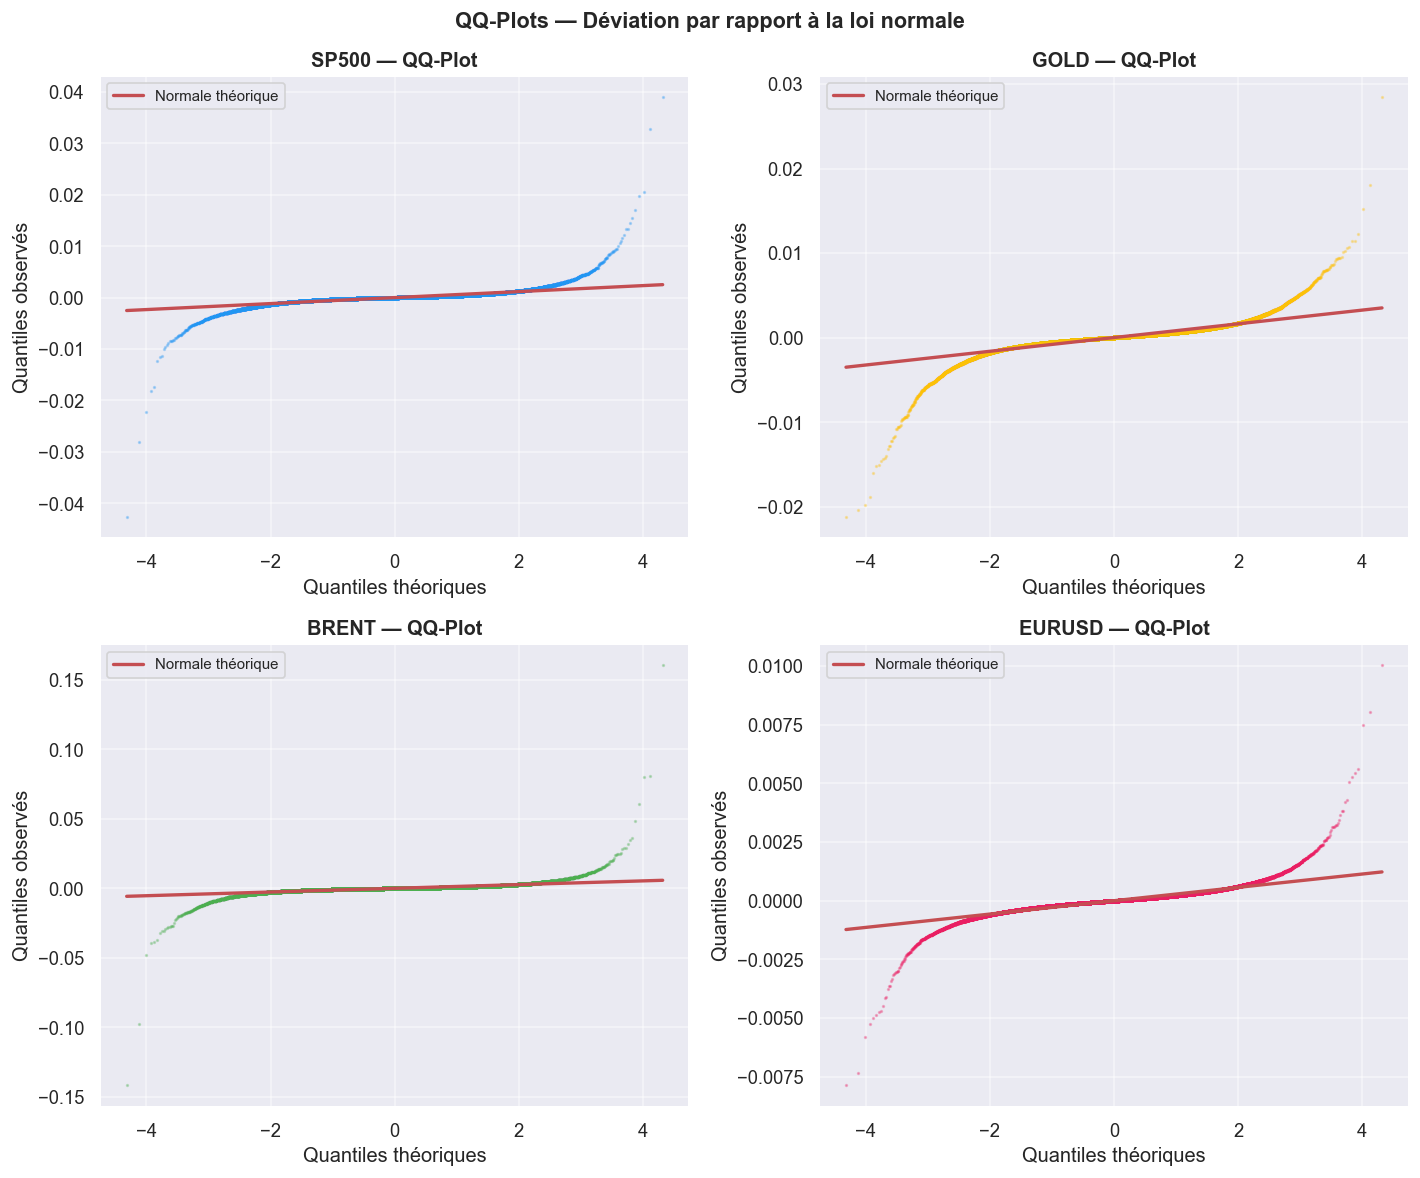

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, name in zip(axes, df_returns.columns):
    r = df_returns[name].dropna()
    (osm, osr), (slope, intercept, _) = stats.probplot(r, dist='norm')
    ax.scatter(osm, osr, s=1, alpha=0.3, color=COLORS[name])
    ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2, label='Normale théorique')
    ax.set_title(f'{name} — QQ-Plot', fontweight='bold')
    ax.set_xlabel('Quantiles théoriques'); ax.set_ylabel('Quantiles observés'); ax.legend(fontsize=9)
plt.suptitle('QQ-Plots — Déviation par rapport à la loi normale', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [13]:
print('=== Test de Jarque-Bera (H0 : normalité) ===')
print(f"{'Actif':8s} {'Stat JB':>14s} {'p-value':>10s} {'Décision':>22s}")
print('-' * 58)
for name in df_returns.columns:
    jb, p = jarque_bera(df_returns[name])
    dec = '❌ Rejette normalité' if p < 0.05 else '✅ Ne rejette pas'
    print(f'{name:8s} {jb:>14.2f} {p:>10.4f} {dec:>22s}')

=== Test de Jarque-Bera (H0 : normalité) ===
Actif           Stat JB    p-value               Décision
----------------------------------------------------------
SP500      544982681.27     0.0000    ❌ Rejette normalité
GOLD         8597836.40     0.0000    ❌ Rejette normalité
BRENT     7676921147.72     0.0000    ❌ Rejette normalité
EURUSD       9813400.98     0.0000    ❌ Rejette normalité


## 7. Tests de Stationnarité (ADF)

In [14]:
print('=== Test ADF — H0 : racine unitaire (non-stationnaire) ===')
print(f"{'Actif':8s} {'Série':12s} {'ADF stat':>10s} {'p-value':>10s} {'Val. crit 5%':>13s} {'Stationnaire':>14s}")
print('-' * 72)
for name, df in datasets.items():
    for label, series in [('Prix close', df['close']), ('Log return', df['log_return'])]:
        stat, p, cv = adf_test(series)
        dec = '✅ Oui' if p < 0.05 else '❌ Non'
        print(f"{name:8s} {label:12s} {stat:>10.4f} {p:>10.4f} {cv['5%']:>13.2f} {dec:>14s}")

=== Test ADF — H0 : racine unitaire (non-stationnaire) ===
Actif    Série          ADF stat    p-value  Val. crit 5%   Stationnaire
------------------------------------------------------------------------
SP500    Prix close      -0.9057     0.9900         -2.86          ❌ Non
SP500    Log return    -315.7103     0.0100         -2.86          ✅ Oui
GOLD     Prix close      -0.7095     0.9900         -2.86          ❌ Non
GOLD     Log return    -314.3515     0.0100         -2.86          ✅ Oui
BRENT    Prix close      -2.1939     0.9900         -2.86          ❌ Non
BRENT    Log return    -322.4311     0.0100         -2.86          ✅ Oui
EURUSD   Prix close      -1.5793     0.9900         -2.86          ❌ Non
EURUSD   Log return    -322.6345     0.0100         -2.86          ✅ Oui


## 8. Autocorrélations (ACF / Ljung-Box)

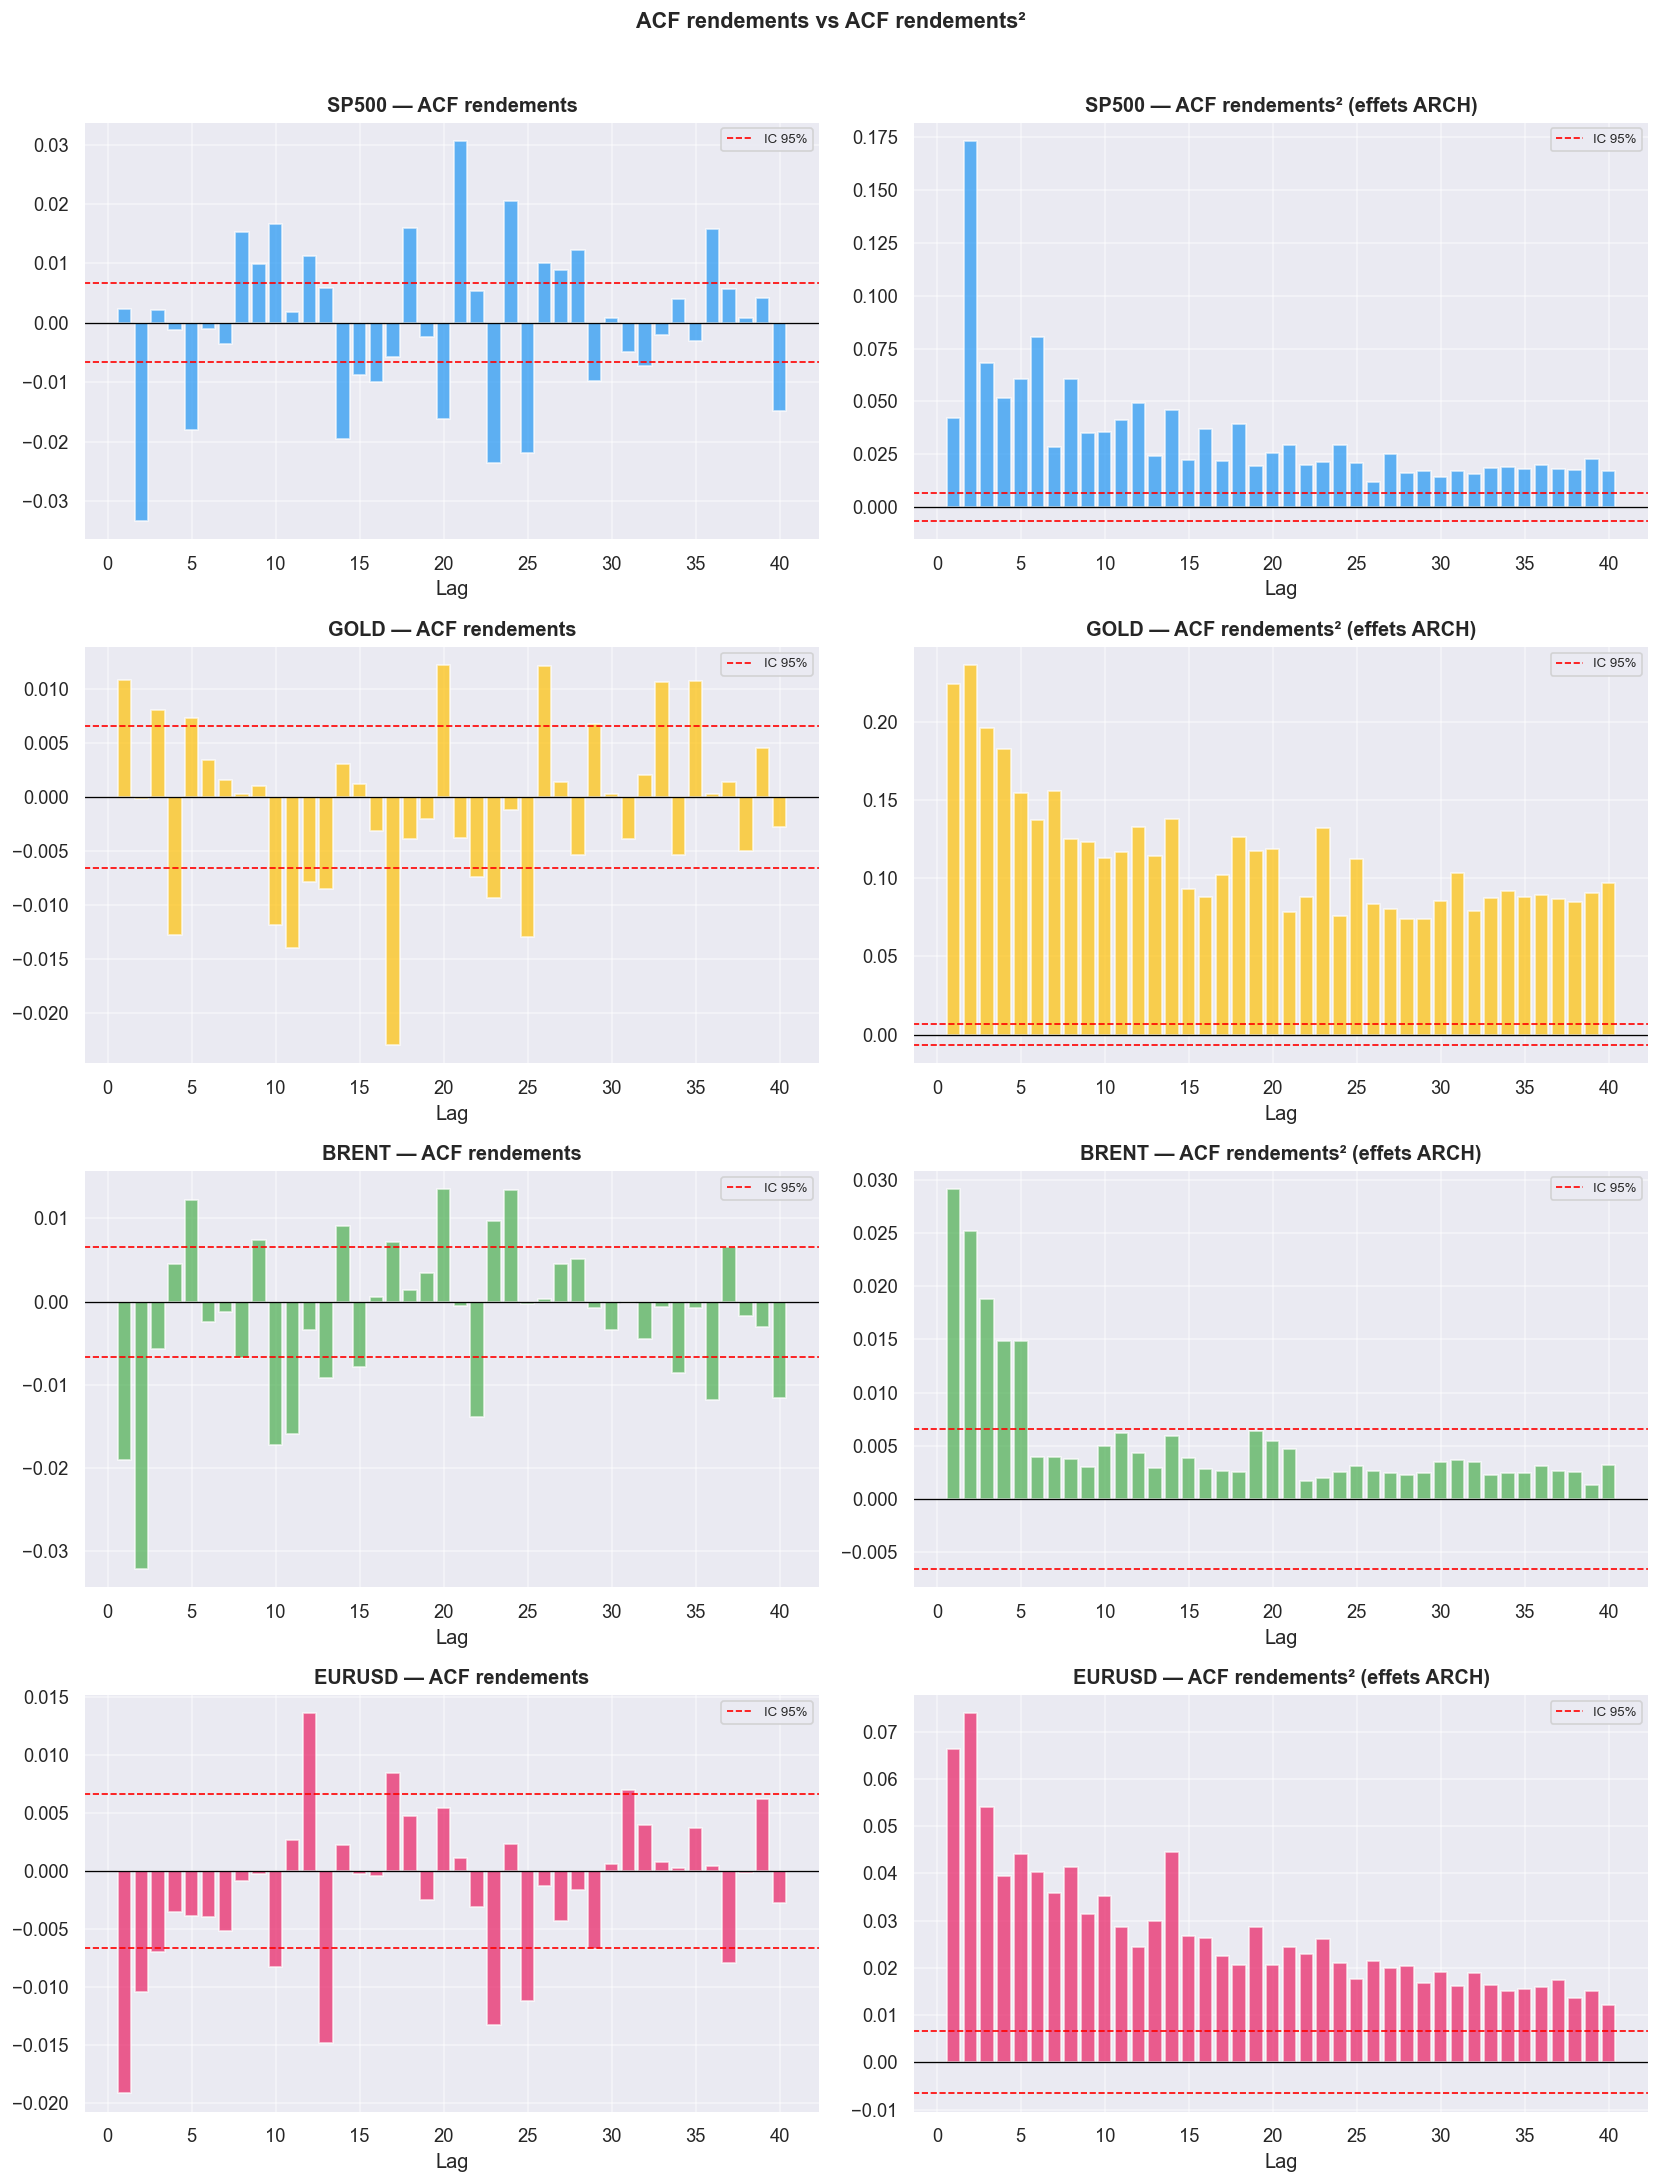

In [15]:
NLAGS = 40
conf  = 1.96 / np.sqrt(len(df_returns))

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
for i, name in enumerate(df_returns.columns):
    r, r2 = df_returns[name].dropna(), df_returns[name].dropna() ** 2
    acf_r, acf_r2 = compute_acf(r, nlags=NLAGS), compute_acf(r2, nlags=NLAGS)
    lags = np.arange(NLAGS + 1)
    for j, (acf_vals, title) in enumerate([
        (acf_r,  f'{name} — ACF rendements'),
        (acf_r2, f'{name} — ACF rendements² (effets ARCH)')
    ]):
        ax = axes[i, j]
        ax.bar(lags[1:], acf_vals[1:], color=COLORS[name], alpha=0.7)
        ax.axhline(0, color='black', lw=0.8)
        ax.axhline( conf, color='red', lw=1, linestyle='--', label='IC 95%')
        ax.axhline(-conf, color='red', lw=1, linestyle='--')
        ax.set_title(title, fontweight='bold'); ax.set_xlabel('Lag'); ax.legend(fontsize=8)
plt.suptitle('ACF rendements vs ACF rendements²', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [16]:
print("=== Test de Ljung-Box (H0 : pas d'autocorrélation) ===")
print(f"{'Actif':8s} {'Série':12s} {'Lag':>5s} {'Stat Q':>10s} {'p-value':>10s} {'Décision':>28s}")
print('-' * 78)
for name in df_returns.columns:
    r, r2 = df_returns[name].dropna(), df_returns[name].dropna() ** 2
    for lag in [10, 20]:
        q_r, p_r   = ljung_box(r,  lag)
        q_r2, p_r2 = ljung_box(r2, lag)
        print(f"{name:8s} {'Rendements':12s} {lag:>5d} {q_r:>10.2f} {p_r:>10.4f} {'❌ Autocorrélation' if p_r < 0.05 else '✅ Indépendant':>28s}")
        print(f"{name:8s} {'Rendements²':12s} {lag:>5d} {q_r2:>10.2f} {p_r2:>10.4f} {'❌ Effet ARCH détecté' if p_r2 < 0.05 else "✅ Pas d'effet ARCH":>28s}")
    print()

SyntaxError: invalid character in identifier (1574234675.py, line 10)

## 9. Analyse de la Volatilité

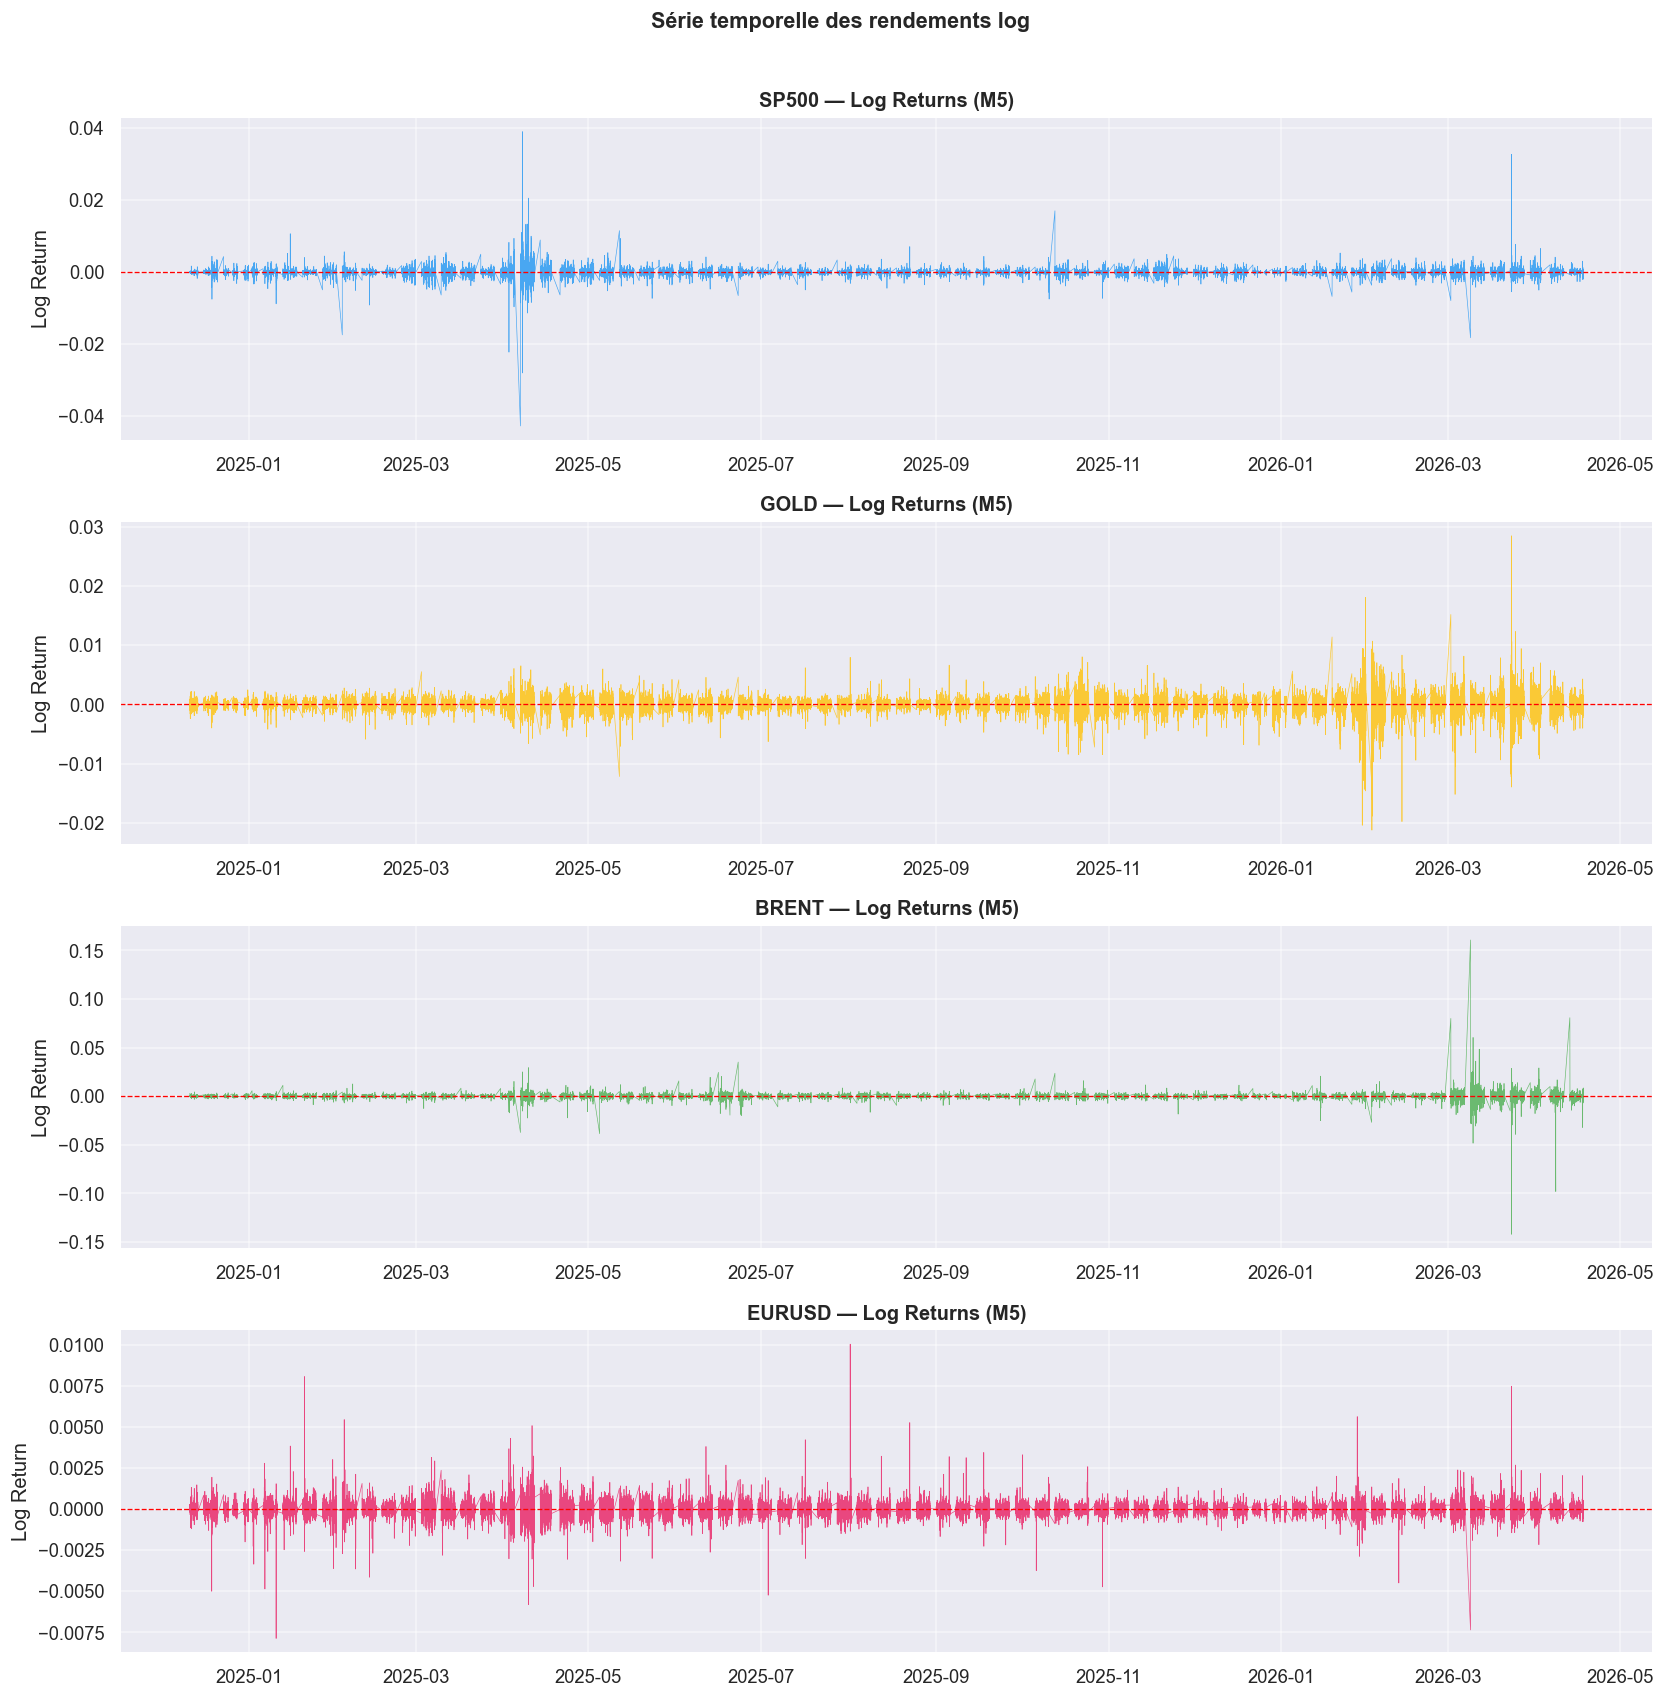

In [17]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
for ax, name in zip(axes, df_returns.columns):
    ax.plot(df_returns[name], lw=0.4, color=COLORS[name], alpha=0.8)
    ax.axhline(0, color='red', lw=0.8, linestyle='--')
    ax.set_title(f'{name} — Log Returns (M5)', fontweight='bold'); ax.set_ylabel('Log Return')
plt.suptitle('Série temporelle des rendements log', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

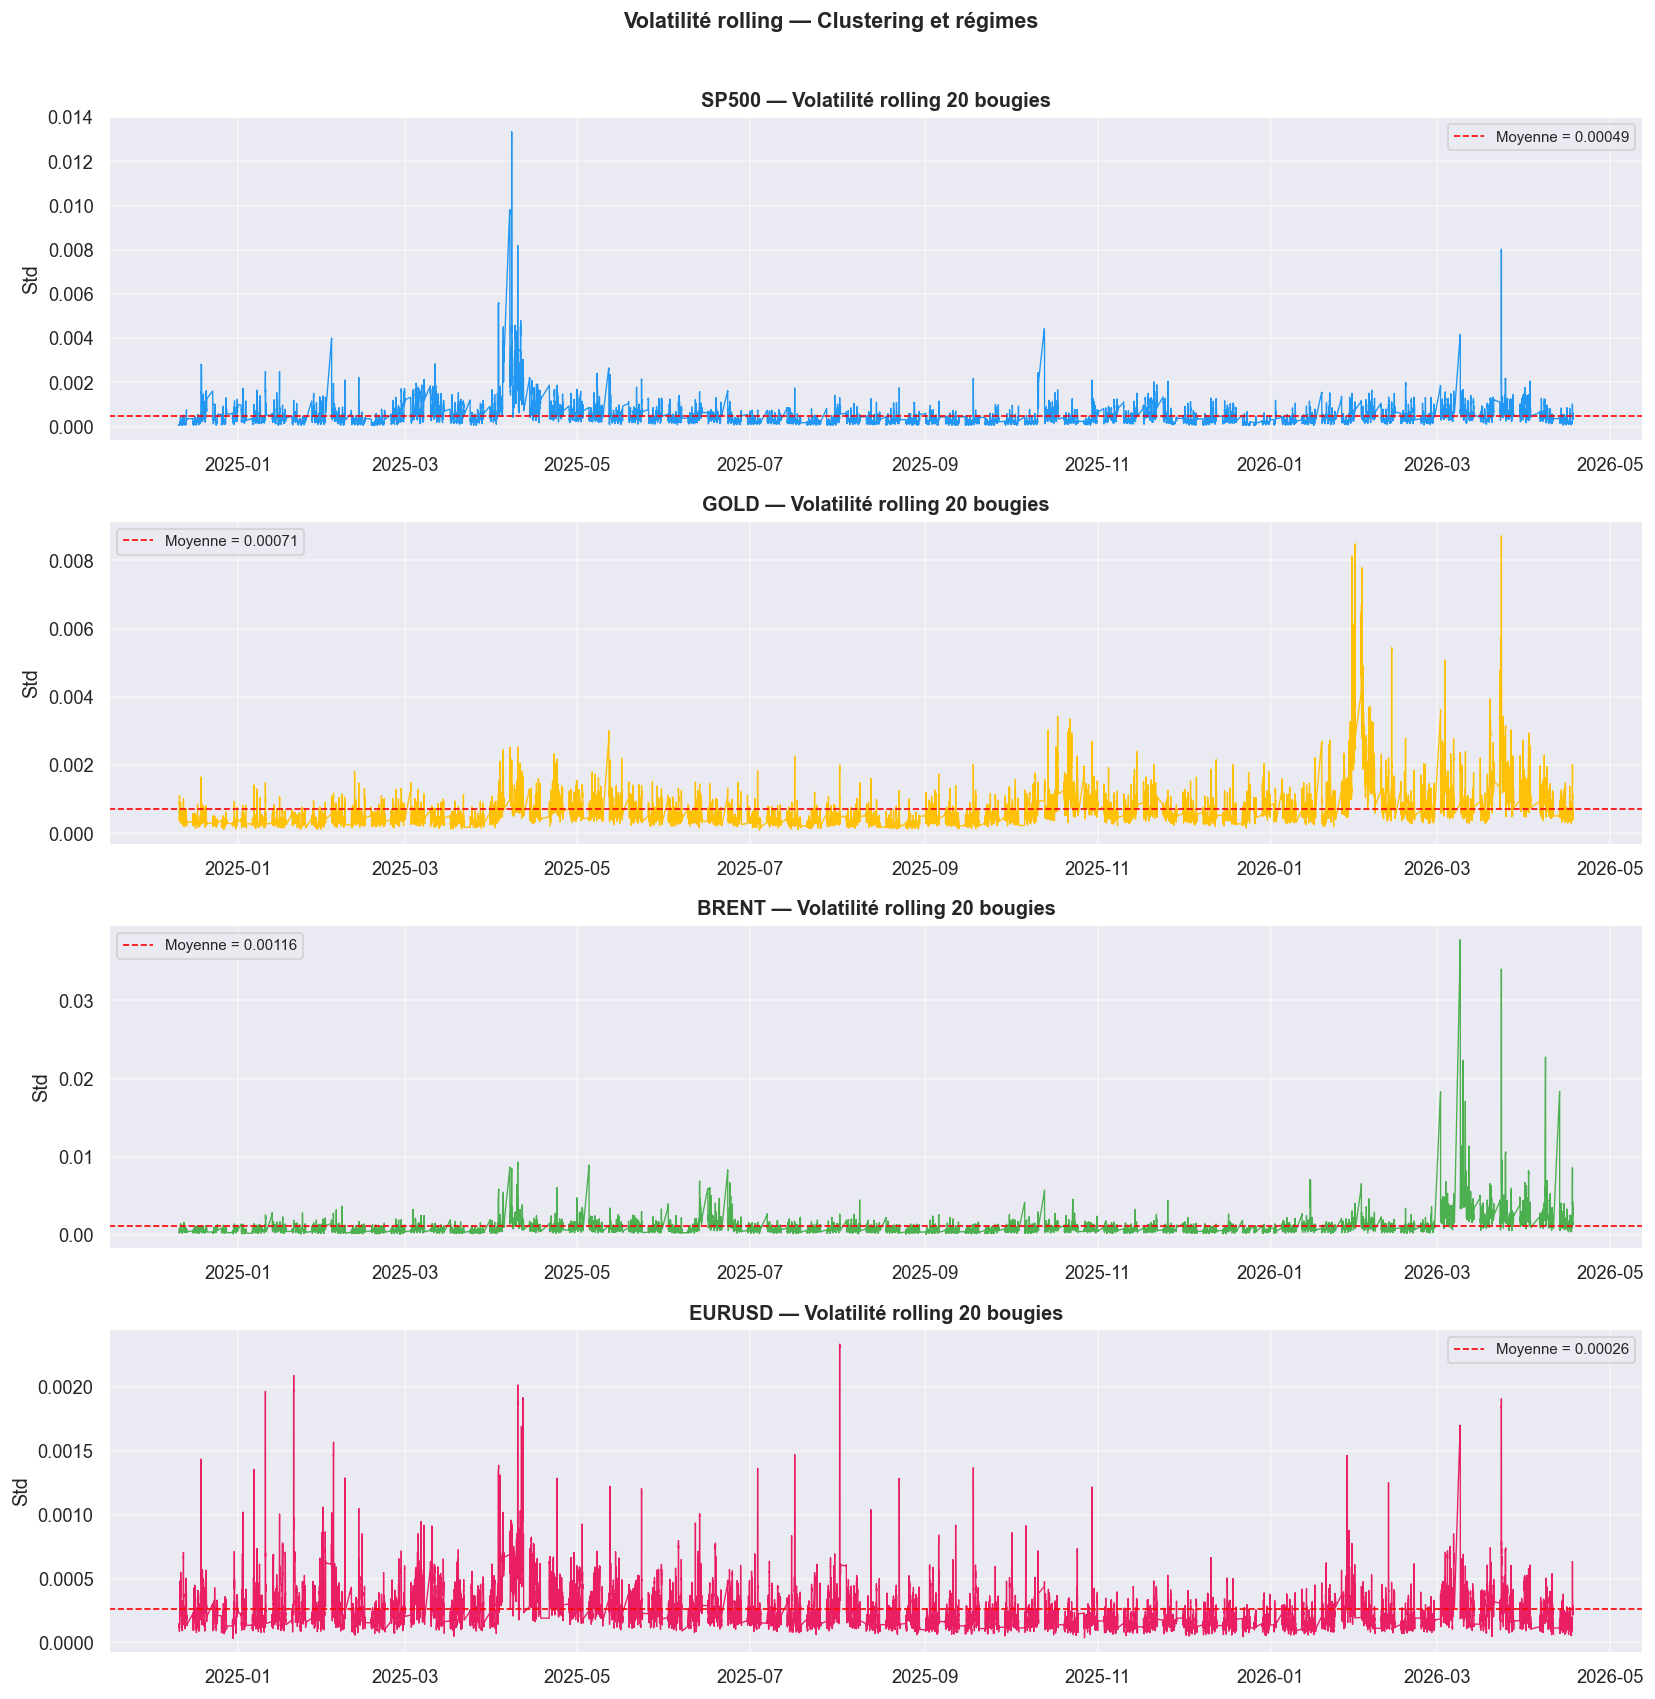

In [18]:
WINDOW = 20
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
for ax, name in zip(axes, df_returns.columns):
    vol = df_returns[name].rolling(WINDOW).std()
    ax.plot(vol, lw=0.8, color=COLORS[name])
    ax.axhline(vol.mean(), color='red', lw=1, linestyle='--', label=f'Moyenne = {vol.mean():.5f}')
    ax.set_title(f'{name} — Volatilité rolling {WINDOW} bougies', fontweight='bold')
    ax.set_ylabel('Std'); ax.legend(fontsize=9)
plt.suptitle('Volatilité rolling — Clustering et régimes', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

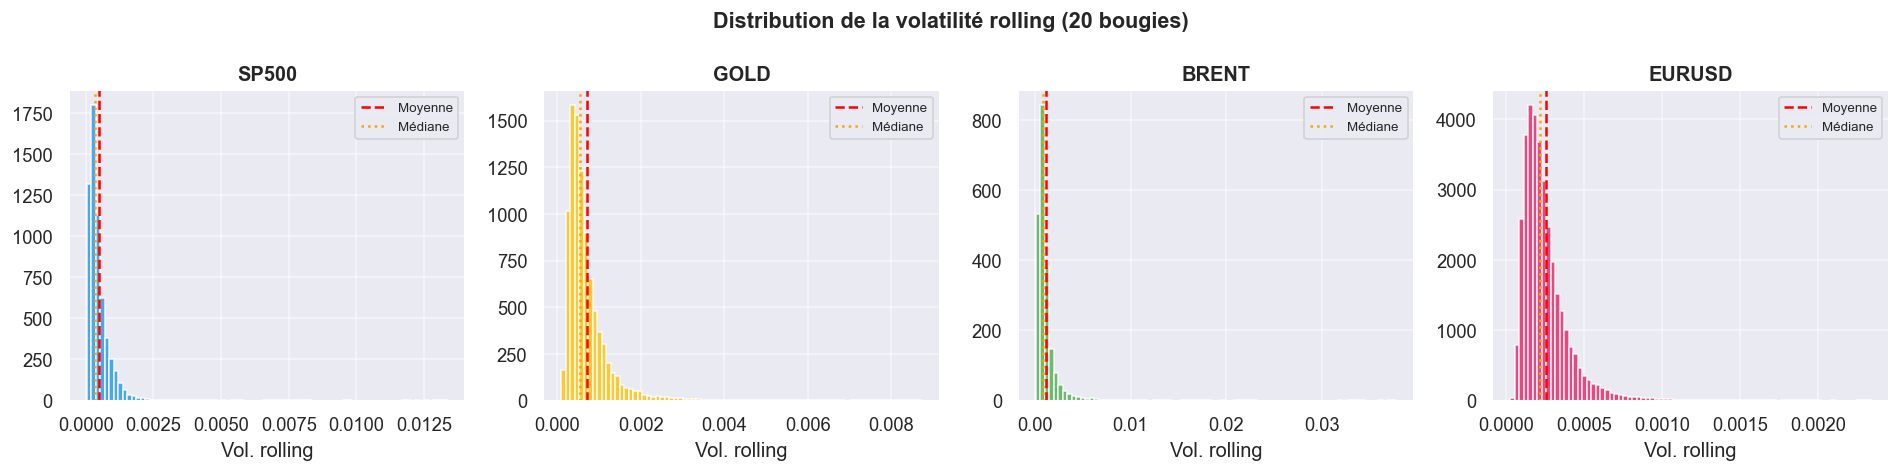

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, name in zip(axes, df_returns.columns):
    vol = df_returns[name].rolling(WINDOW).std().dropna()
    ax.hist(vol, bins=80, density=True, color=COLORS[name], alpha=0.8)
    ax.axvline(vol.mean(),   color='red',    lw=1.5, linestyle='--', label='Moyenne')
    ax.axvline(vol.median(), color='orange', lw=1.5, linestyle=':',  label='Médiane')
    ax.set_title(f'{name}', fontweight='bold'); ax.set_xlabel('Vol. rolling'); ax.legend(fontsize=8)
plt.suptitle('Distribution de la volatilité rolling (20 bougies)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

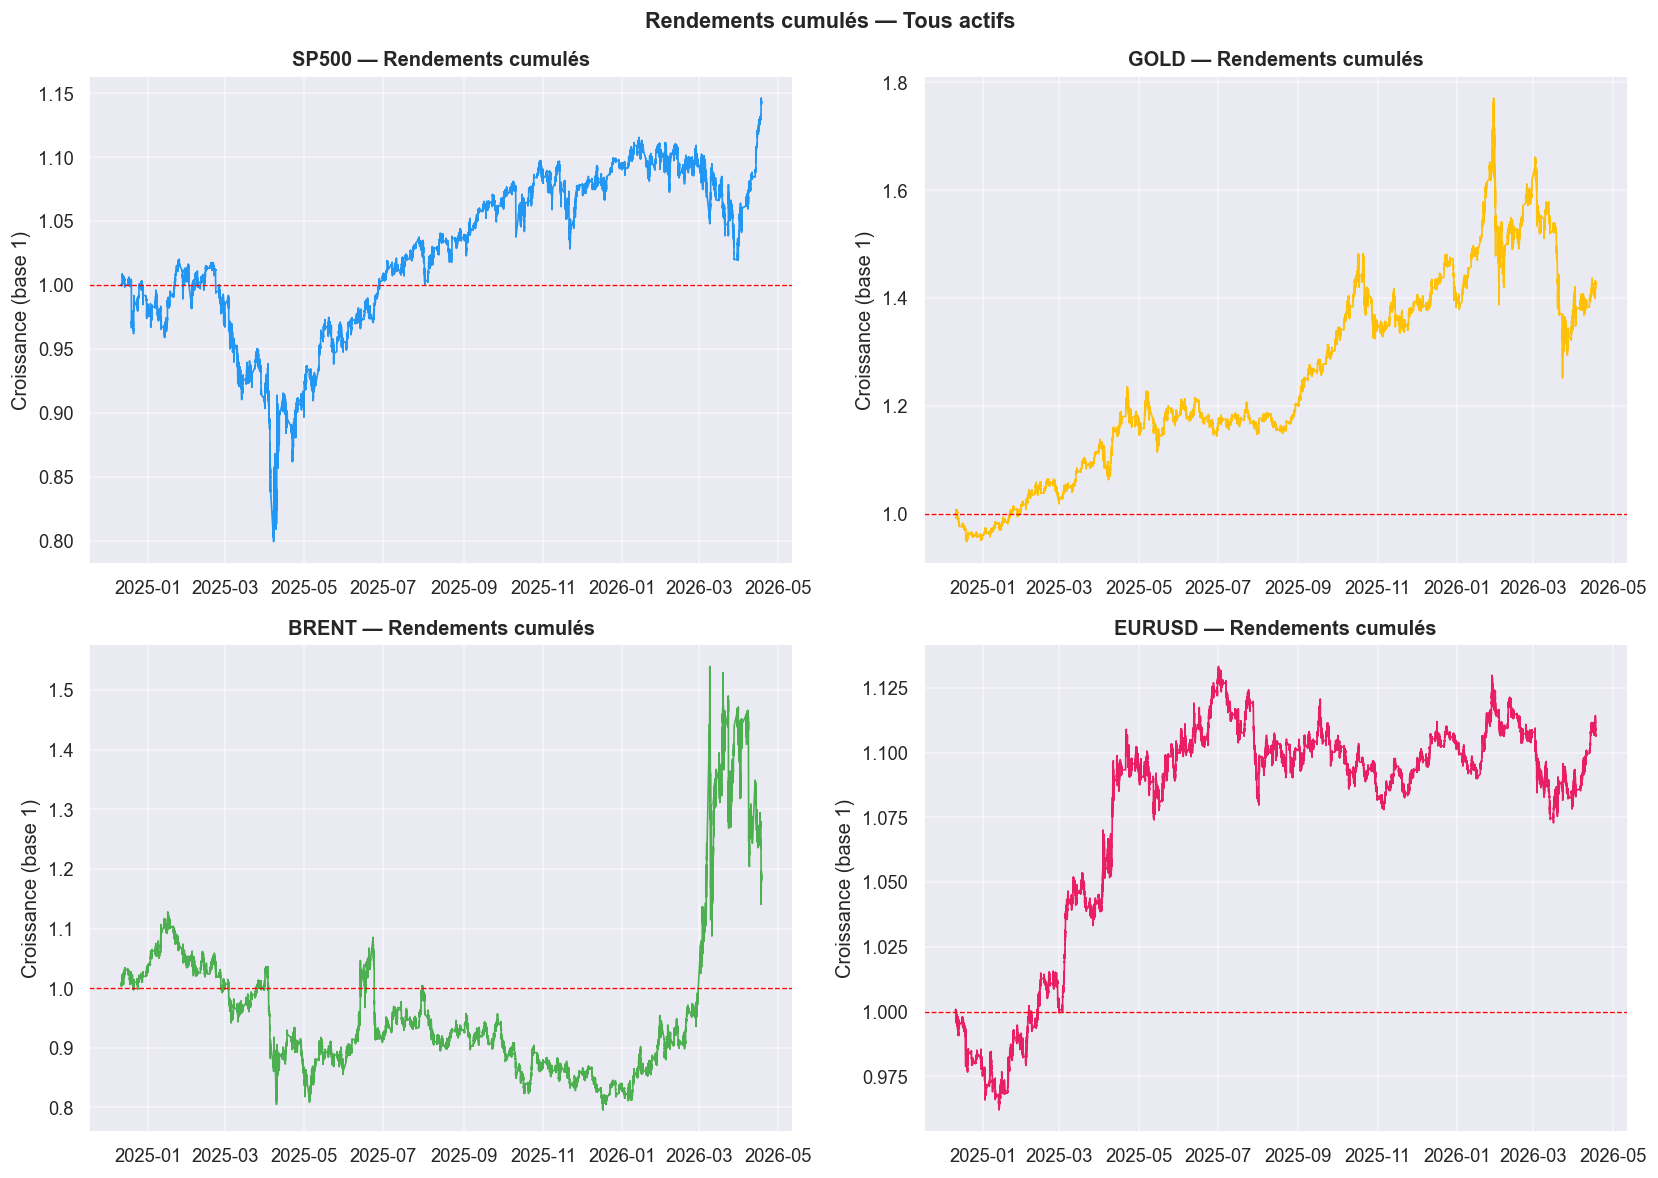

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, name in zip(axes, df_returns.columns):
    cum = np.exp(df_returns[name].dropna().cumsum())
    ax.plot(cum, lw=1, color=COLORS[name])
    ax.axhline(1, color='red', lw=0.8, linestyle='--')
    ax.set_title(f'{name} — Rendements cumulés', fontweight='bold'); ax.set_ylabel('Croissance (base 1)')
plt.suptitle('Rendements cumulés — Tous actifs', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 10. Tail Risk — VaR et CVaR

In [21]:
risk_rows = []
for name in df_returns.columns:
    r, row = df_returns[name].dropna(), {'Actif': name}
    for alpha in [0.05, 0.01]:
        var  = r.quantile(alpha)
        cvar = r[r <= var].mean()
        conf = int((1 - alpha) * 100)
        row[f'VaR {conf}%'] = round(var, 6); row[f'CVaR {conf}%'] = round(cvar, 6)
    risk_rows.append(row)
display(pd.DataFrame(risk_rows).set_index('Actif'))

,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%
Actif,,,,
SP500,-0.000858,-0.001607,-0.001977,-0.003122
GOLD,-0.001186,-0.002178,-0.002633,-0.004259
BRENT,-0.001856,-0.003602,-0.004173,-0.007597
EURUSD,-0.000433,-0.000688,-0.000797,-0.001198


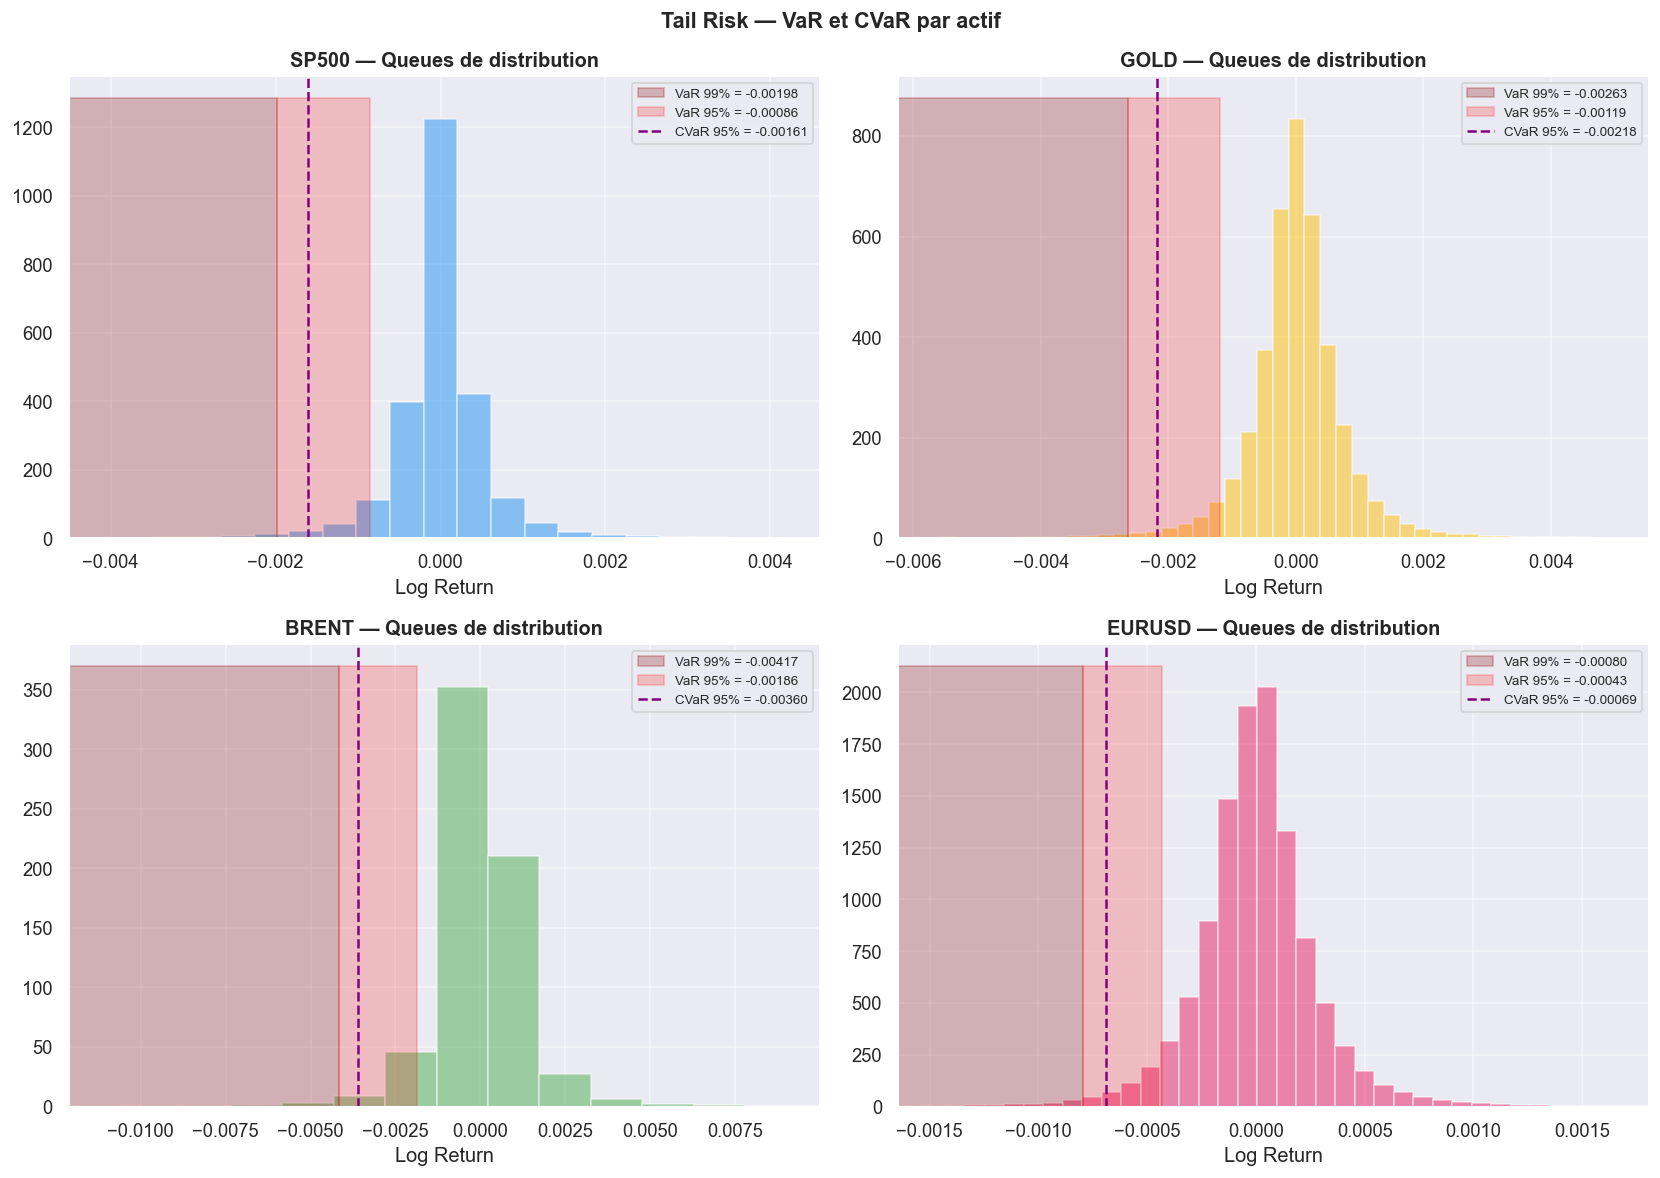

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, name in zip(axes, df_returns.columns):
    r = df_returns[name].dropna()
    var95, var99, cvar95 = r.quantile(0.05), r.quantile(0.01), r[r <= r.quantile(0.05)].mean()
    ax.hist(r, bins=200, density=True, color=COLORS[name], alpha=0.5)
    ymax = ax.get_ylim()[1] or 1
    ax.fill_betweenx([0, ymax], r.min(), var99, alpha=0.25, color='darkred', label=f'VaR 99% = {var99:.5f}')
    ax.fill_betweenx([0, ymax], var99, var95,   alpha=0.20, color='red',     label=f'VaR 95% = {var95:.5f}')
    ax.axvline(cvar95, color='purple', lw=1.5, linestyle='--', label=f'CVaR 95% = {cvar95:.5f}')
    ax.set_xlim(r.quantile(0.001), r.quantile(0.999))
    ax.set_title(f'{name} — Queues de distribution', fontweight='bold')
    ax.set_xlabel('Log Return'); ax.legend(fontsize=8)
plt.suptitle('Tail Risk — VaR et CVaR par actif', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 11. Corrélations

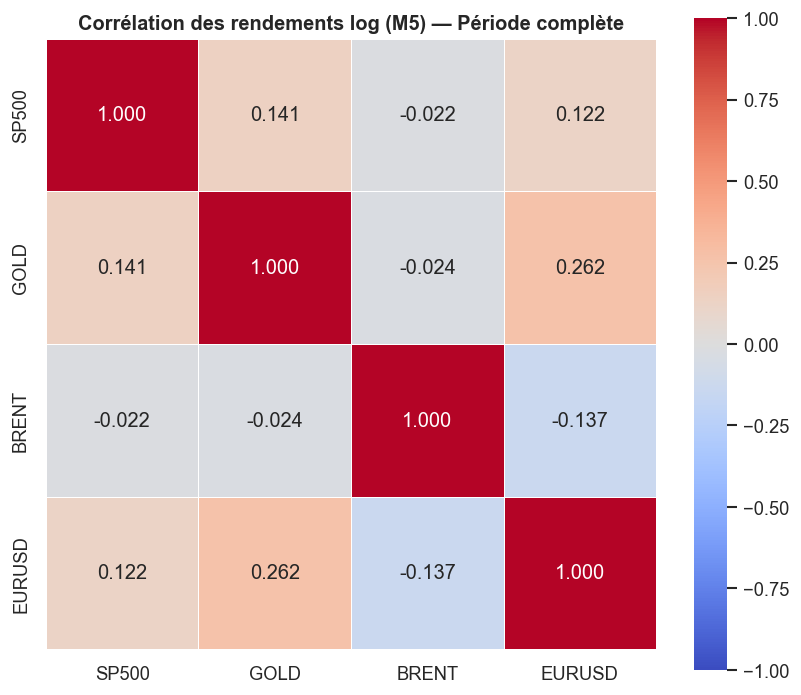

In [23]:
plt.figure(figsize=(7, 6))
sns.heatmap(df_returns.corr(), annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Corrélation des rendements log (M5) — Période complète', fontweight='bold')
plt.tight_layout(); plt.show()

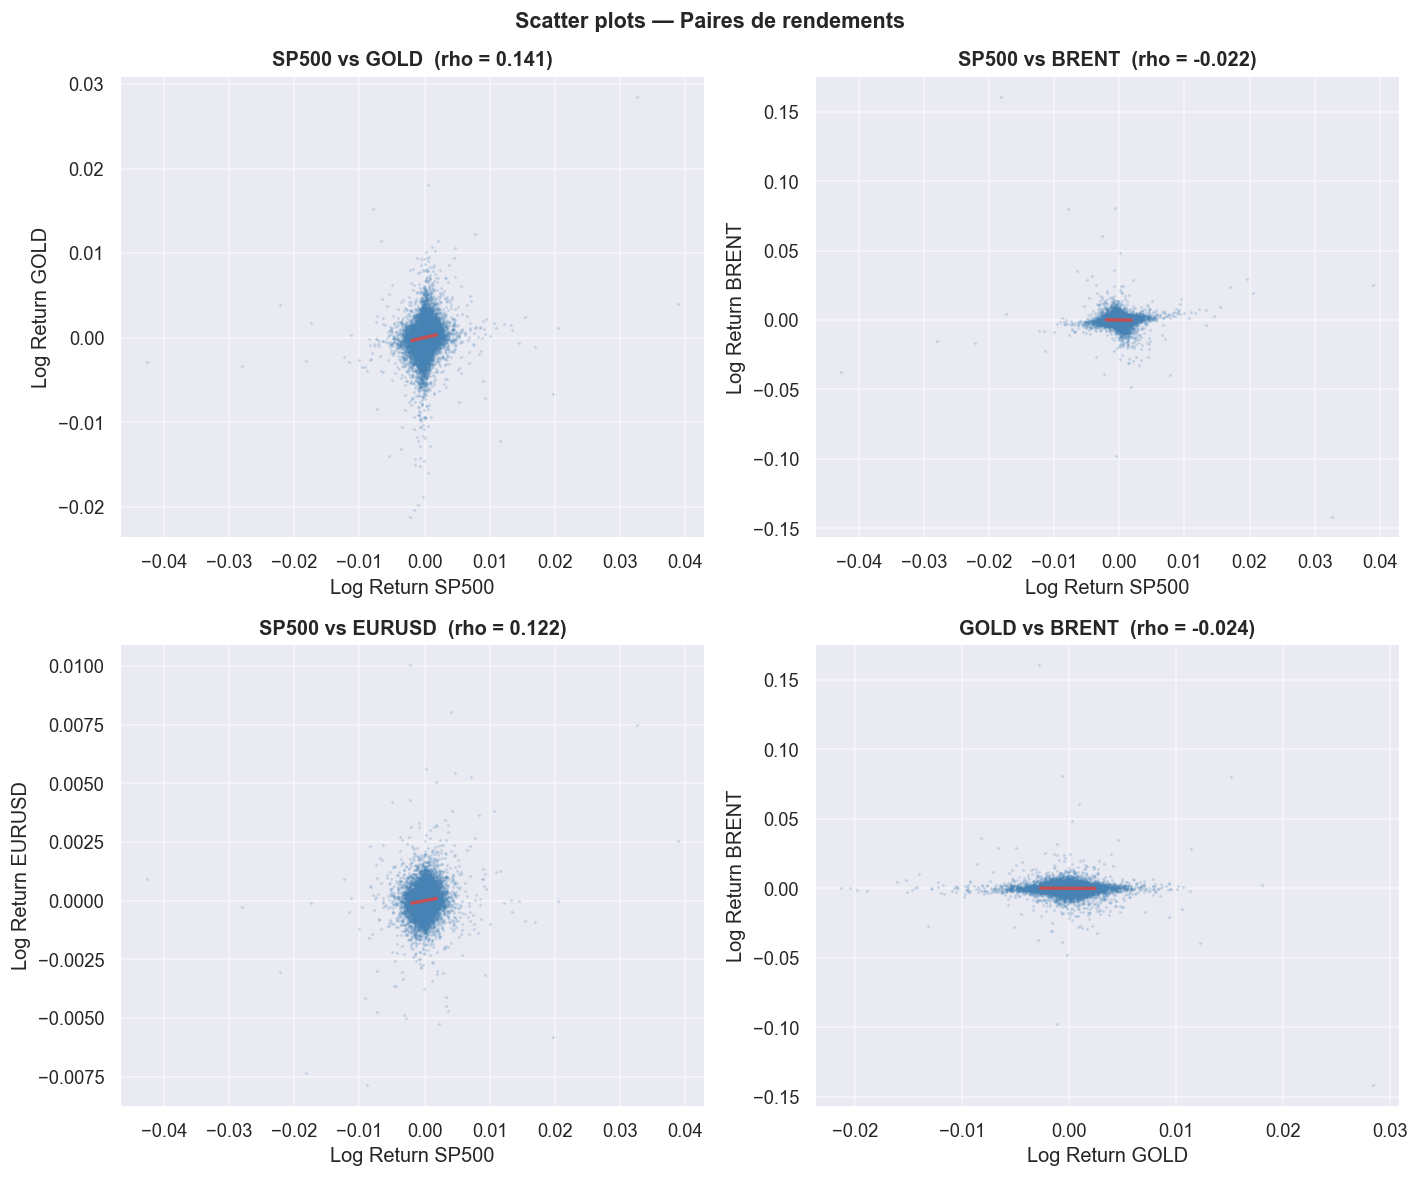

In [24]:
pairs = [('SP500', 'GOLD'), ('SP500', 'BRENT'), ('SP500', 'EURUSD'), ('GOLD', 'BRENT')]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, (a, b) in zip(axes, pairs):
    x = df_returns[a].dropna()
    y = df_returns[b].reindex(x.index).dropna()
    x = x.reindex(y.index)
    rho = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, s=1, alpha=0.15, color='steelblue')
    m, b_ = np.polyfit(x, y, 1)
    xfit = np.linspace(x.quantile(0.01), x.quantile(0.99), 200)
    ax.plot(xfit, m * xfit + b_, 'r-', lw=2)
    ax.set_title(f'{a} vs {b}  (rho = {rho:.3f})', fontweight='bold')
    ax.set_xlabel(f'Log Return {a}'); ax.set_ylabel(f'Log Return {b}')
plt.suptitle('Scatter plots — Paires de rendements', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

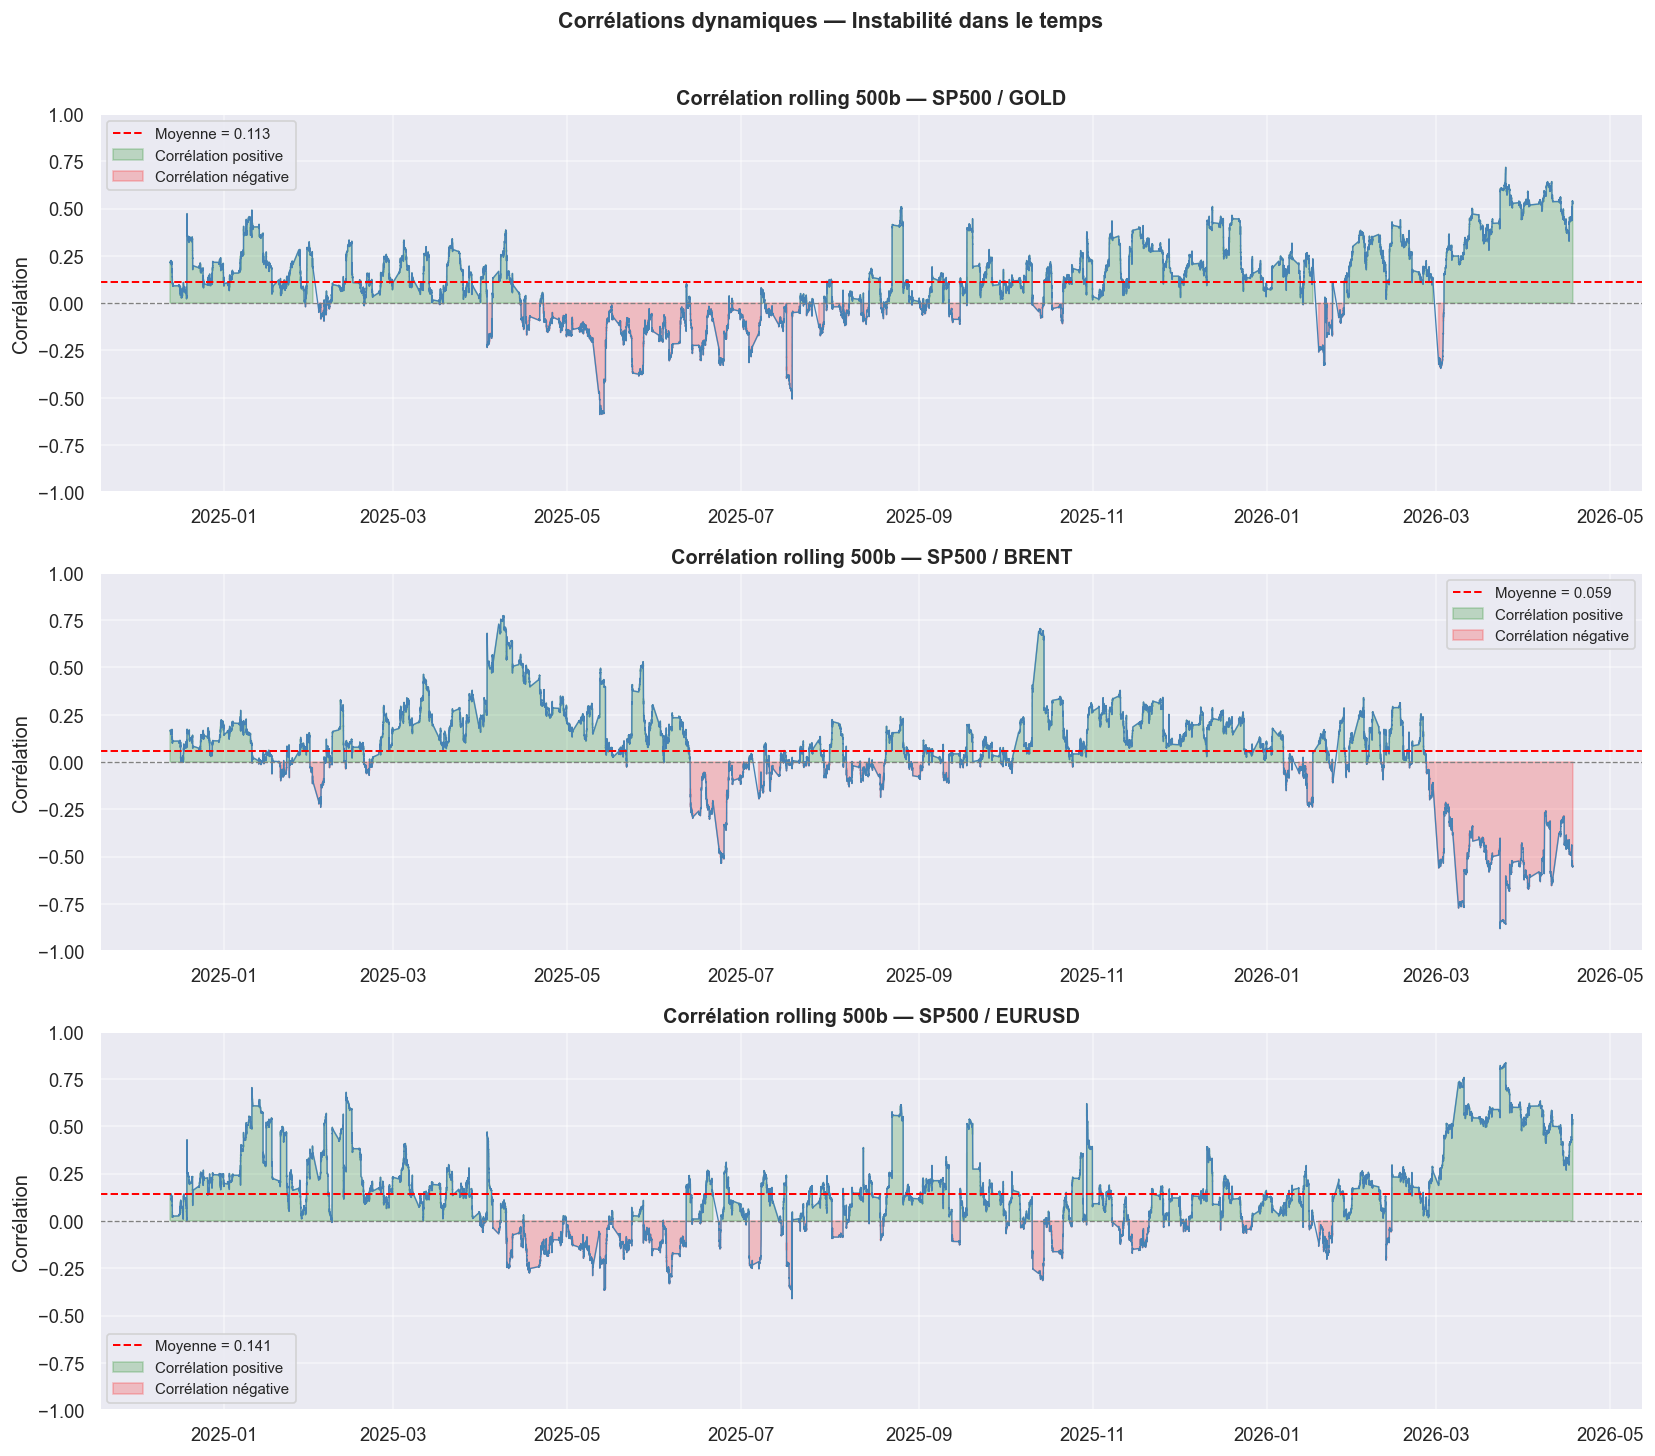

In [25]:
ROLL = 500
pairs_roll = [('SP500', 'GOLD'), ('SP500', 'BRENT'), ('SP500', 'EURUSD')]
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
for ax, (a, b) in zip(axes, pairs_roll):
    rc = df_returns[a].rolling(ROLL).corr(df_returns[b])
    ax.plot(rc, lw=0.8, color='steelblue')
    ax.axhline(0, color='gray', lw=0.8, linestyle='--')
    ax.axhline(rc.mean(), color='red', lw=1.2, linestyle='--', label=f'Moyenne = {rc.mean():.3f}')
    ax.fill_between(rc.index, 0, rc, where=(rc >= 0), alpha=0.2, color='green', label='Corrélation positive')
    ax.fill_between(rc.index, 0, rc, where=(rc  < 0), alpha=0.2, color='red',   label='Corrélation négative')
    ax.set_title(f'Corrélation rolling {ROLL}b — {a} / {b}', fontweight='bold')
    ax.set_ylabel('Corrélation'); ax.set_ylim(-1, 1); ax.legend(fontsize=9)
plt.suptitle('Corrélations dynamiques — Instabilité dans le temps', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 12. Analyse de Persistance des Tendances — SP500 M5

> **Objectif** : Mesurer combien de bougies une tendance persiste naturellement, pour calibrer l'horizon de prédiction et justifier le label Up/Down.
>
> **Broker Admirals** — Spread typique : 0.60 pt — Commission : 0 — **Coût aller-retour : 1.20 pts**

In [26]:
# ── 12.1 Préparation du DataFrame SP500 ──────────────────────────────────────
df_sp = sp500.copy().sort_index()
df_sp = df_sp[~df_sp.index.duplicated(keep='first')].dropna(subset=['close'])
df_sp['log_ret'] = np.log(df_sp['close'] / df_sp['close'].shift(1))

prix_moyen = df_sp['close'].mean()
seuil_pct  = SPREAD_RT / prix_moyen

print('=== Seuil de rentabilité minimum (Admirals) ===')
print(f'  Spread aller-retour : {SPREAD_RT:.2f} points')
print(f'  Prix moyen SP500    : {prix_moyen:.1f} points')
print(f'  Seuil en %          : {seuil_pct*100:.4f}%')
print(f"  → Une position doit bouger > {SPREAD_RT:.2f} pts pour couvrir le spread")

=== Seuil de rentabilité minimum (Admirals) ===
  Spread aller-retour : 1.20 points
  Prix moyen SP500    : 6318.4 points
  Seuil en %          : 0.0190%
  → Une position doit bouger > 1.20 pts pour couvrir le spread


,horizon_bougies,horizon_minutes,move_q25_pts,move_median_pts,move_mean_pts,move_q75_pts,pct_couvre_spread
0,1,5,0.50,1.25,2.197,2.69,52.2
1,2,10,0.75,1.75,3.146,3.75,63.8
2,3,15,0.98,2.25,3.869,4.69,69.7
3,4,20,1.02,2.50,4.486,5.49,73.4
4,6,30,1.29,3.22,5.536,6.75,78.1
5,8,40,1.52,3.75,6.437,7.75,81.0
6,12,60,2.00,4.61,8.004,9.75,84.7
7,18,90,2.50,5.75,9.946,12.13,87.6
8,24,120,2.91,6.75,11.652,14.28,89.5


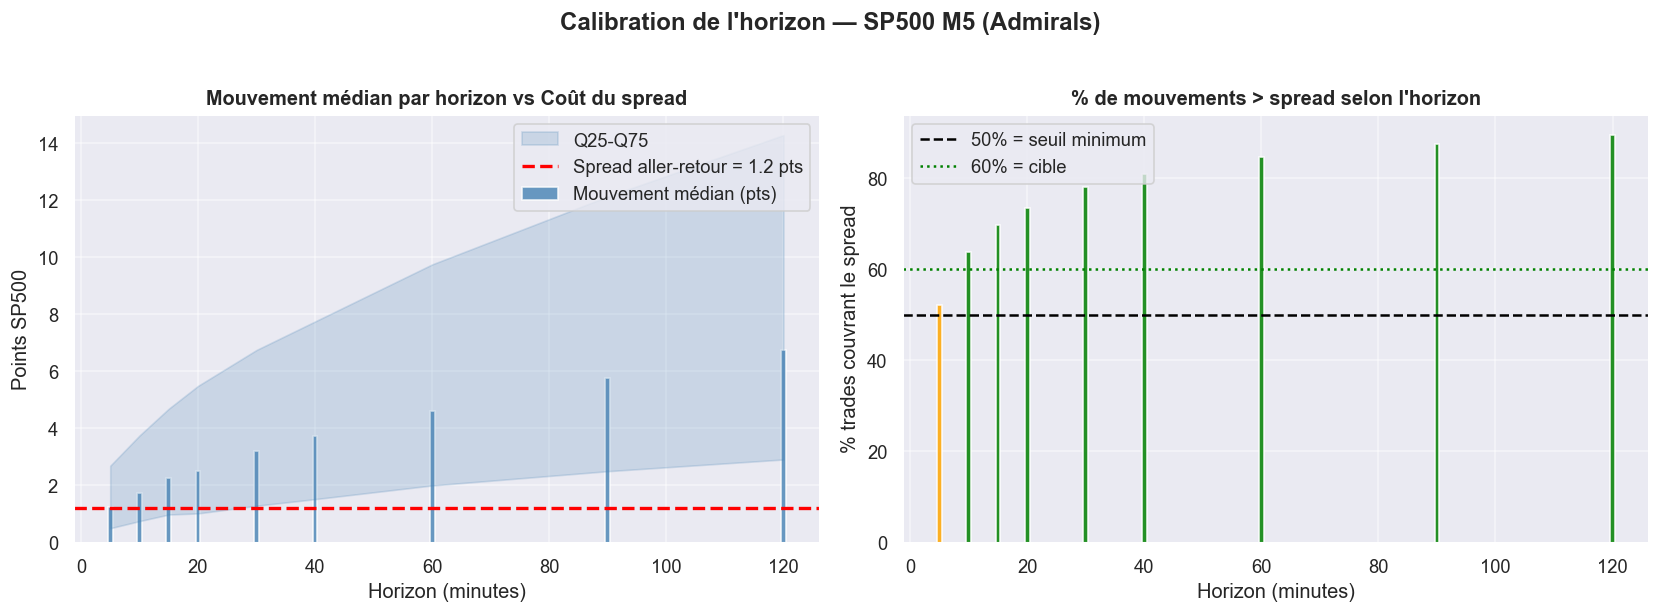

In [27]:
# ── 12.2 Mouvement médian par horizon (1 → 24 bougies) ───────────────────────
HORIZONS = [1, 2, 3, 4, 6, 8, 12, 18, 24]

results = []
for n in HORIZONS:
    move_abs = (df_sp['close'].shift(-n) - df_sp['close']).dropna().abs()
    results.append({
        'horizon_bougies'   : n,
        'horizon_minutes'   : n * 5,
        'move_q25_pts'      : round(move_abs.quantile(0.25), 3),
        'move_median_pts'   : round(move_abs.median(), 3),
        'move_mean_pts'     : round(move_abs.mean(), 3),
        'move_q75_pts'      : round(move_abs.quantile(0.75), 3),
        'pct_couvre_spread' : round((move_abs > SPREAD_RT).mean() * 100, 1),
    })

df_horizons = pd.DataFrame(results)
display(df_horizons)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(df_horizons['horizon_minutes'], df_horizons['move_median_pts'],
       color='steelblue', alpha=0.8, edgecolor='white', label='Mouvement médian (pts)')
ax.fill_between(df_horizons['horizon_minutes'],
                df_horizons['move_q25_pts'], df_horizons['move_q75_pts'],
                alpha=0.2, color='steelblue', label='Q25-Q75')
ax.axhline(SPREAD_RT, color='red', lw=2, linestyle='--',
           label=f'Spread aller-retour = {SPREAD_RT} pts')
ax.set_xlabel('Horizon (minutes)'); ax.set_ylabel('Points SP500')
ax.set_title("Mouvement médian par horizon vs Coût du spread", fontweight='bold'); ax.legend()

ax = axes[1]
colors_bar = ['green' if x >= 60 else ('orange' if x >= 50 else 'red')
               for x in df_horizons['pct_couvre_spread']]
ax.bar(df_horizons['horizon_minutes'], df_horizons['pct_couvre_spread'],
       color=colors_bar, alpha=0.85, edgecolor='white')
ax.axhline(50, color='black', lw=1.5, linestyle='--', label='50% = seuil minimum')
ax.axhline(60, color='green', lw=1.5, linestyle=':', label='60% = cible')
ax.set_xlabel('Horizon (minutes)'); ax.set_ylabel('% trades couvrant le spread')
ax.set_title("% de mouvements > spread selon l'horizon", fontweight='bold'); ax.legend()

plt.suptitle("Calibration de l'horizon — SP500 M5 (Admirals)", fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

=== Distribution des longueurs de runs ===
count    48188.00
mean         1.99
std          1.38
min          1.00
25%          1.00
50%          2.00
75%          2.00
max         16.00
Name: length, dtype: float64

  Runs 1 bougie   : 49.7%  ← bruit pur
  Runs 2 bougies  : 25.3%
  Runs 3 bougies  : 12.6%  ← tendance 15min
  Runs 4+ bougies : 12.4%  ← tendance 20min+
  Runs 6+ bougies : 2.9%  ← tendance 30min+


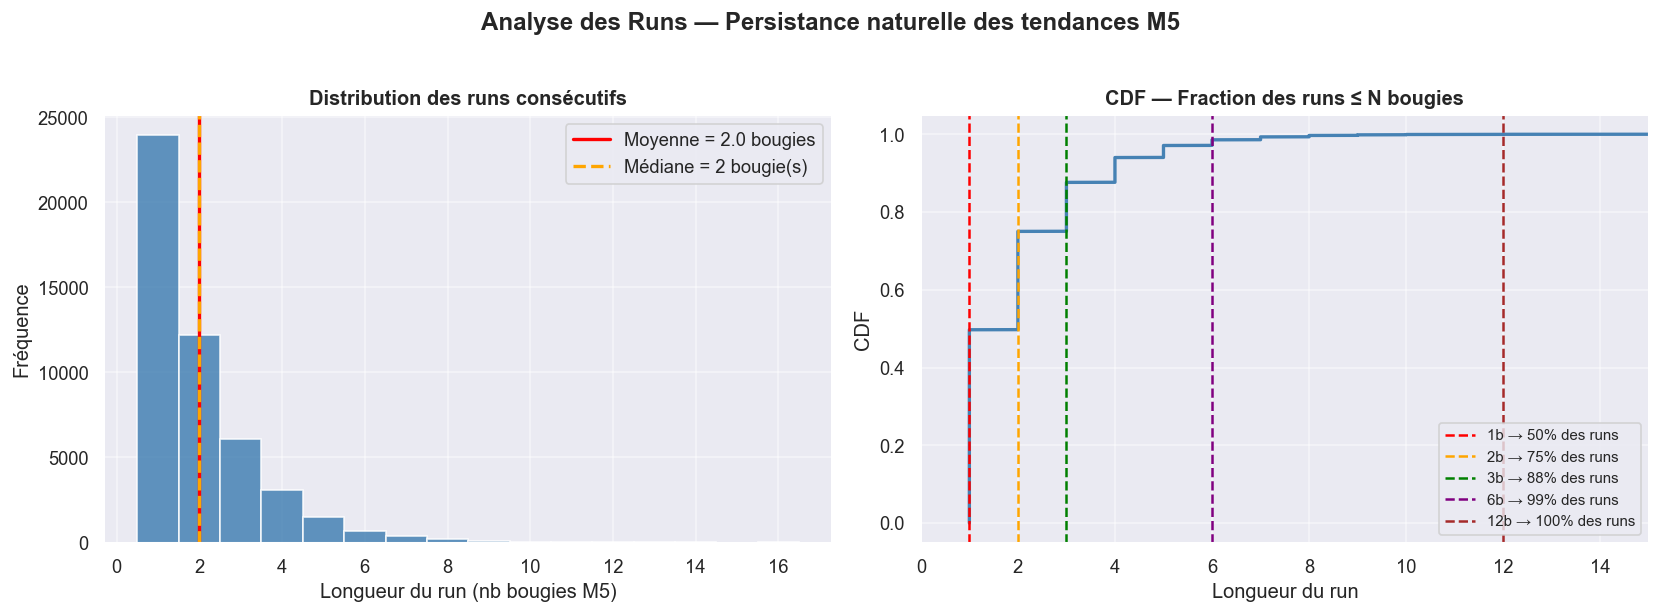

In [28]:
# ── 12.3 Analyse des RUNS — durée naturelle des tendances ────────────────────
df_sp['direction'] = np.sign(df_sp['close'] - df_sp['close'].shift(1))
series = df_sp['direction'].dropna()
series = series[series != 0]

runs = []
for key, group in groupby(zip(series.index, series.values), key=lambda x: x[1]):
    g = list(group)
    runs.append({'direction': int(key), 'length': len(g), 'start': g[0][0], 'end': g[-1][0]})
runs_df = pd.DataFrame(runs)

print('=== Distribution des longueurs de runs ===')
print(runs_df['length'].describe().round(2))
print(f"\n  Runs 1 bougie   : {(runs_df['length']==1).mean()*100:.1f}%  ← bruit pur")
print(f"  Runs 2 bougies  : {(runs_df['length']==2).mean()*100:.1f}%")
print(f"  Runs 3 bougies  : {(runs_df['length']==3).mean()*100:.1f}%  ← tendance 15min")
print(f"  Runs 4+ bougies : {(runs_df['length']>=4).mean()*100:.1f}%  ← tendance 20min+")
print(f"  Runs 6+ bougies : {(runs_df['length']>=6).mean()*100:.1f}%  ← tendance 30min+")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.arange(1, min(runs_df['length'].max(), 20) + 2) - 0.5
ax.hist(runs_df['length'].clip(upper=20), bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(runs_df['length'].mean(),   color='red',    lw=2, label=f"Moyenne = {runs_df['length'].mean():.1f} bougies")
ax.axvline(runs_df['length'].median(), color='orange', lw=2, linestyle='--', label=f"Médiane = {runs_df['length'].median():.0f} bougie(s)")
ax.set_xlabel('Longueur du run (nb bougies M5)'); ax.set_ylabel('Fréquence')
ax.set_title('Distribution des runs consécutifs', fontweight='bold'); ax.legend()

ax = axes[1]
lengths = np.sort(runs_df['length'].values)
cdf = np.arange(1, len(lengths)+1) / len(lengths)
ax.plot(lengths, cdf, color='steelblue', lw=2)
for n, col in [(1,'red'), (2,'orange'), (3,'green'), (6,'purple'), (12,'brown')]:
    pct = (runs_df['length'] <= n).mean()
    ax.axvline(n, color=col, lw=1.5, linestyle='--', label=f'{n}b → {pct*100:.0f}% des runs')
ax.set_xlim(0, 15); ax.set_xlabel('Longueur du run'); ax.set_ylabel('CDF')
ax.set_title("CDF — Fraction des runs ≤ N bougies", fontweight='bold'); ax.legend(fontsize=9)

plt.suptitle('Analyse des Runs — Persistance naturelle des tendances M5', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

,horizon_bougies,horizon_minutes,autocorrelation,persistance_dir,move_moyen_pts
0,1,5,0.0016,48.0,2.20
1,2,10,-0.0322,48.3,3.15
2,3,15,0.0012,48.5,3.87
3,4,20,-0.0012,48.5,4.49
4,6,30,-0.0007,49.1,5.54
5,8,40,0.0170,49.1,6.44
6,12,60,0.0097,49.3,8.00
7,18,90,0.0145,49.5,9.95
8,24,120,0.0192,49.5,11.65


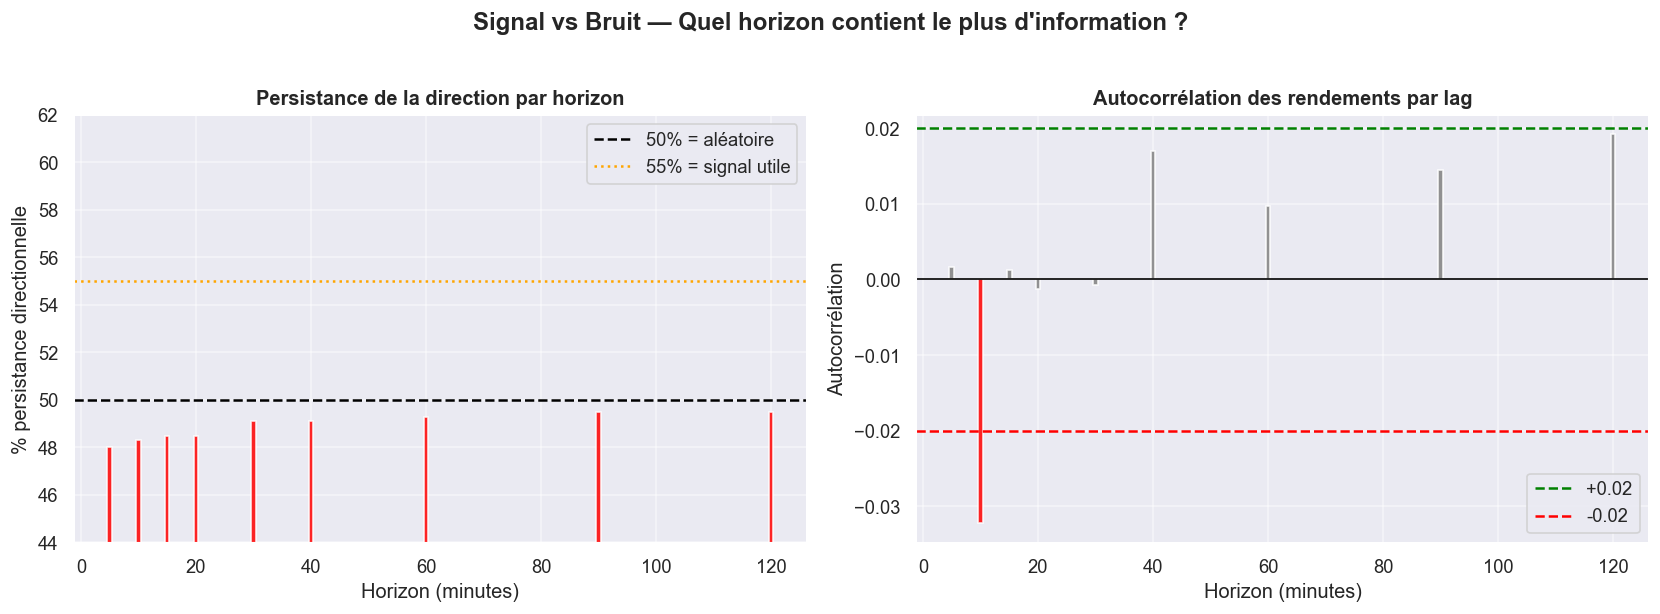


→ > 50% = momentum (tendance continue)  |  < 50% = mean-reversion (retournement)


In [29]:
# ── 12.4 Persistance directionnelle et autocorrélation par horizon ────────────
ratios = []
for n in HORIZONS:
    net_move        = df_sp['close'].shift(-n) - df_sp['close']
    autocorr        = df_sp['log_ret'].autocorr(lag=n)
    direction_now   = np.sign(df_sp['close'] - df_sp['close'].shift(1))
    direction_futur = np.sign(net_move)
    mask = direction_now.notna() & direction_futur.notna() & (direction_now != 0)
    persistence = (direction_now[mask] == direction_futur[mask]).mean()
    ratios.append({
        'horizon_bougies' : n, 'horizon_minutes' : n * 5,
        'autocorrelation' : round(autocorr, 4),
        'persistance_dir' : round(persistence * 100, 1),
        'move_moyen_pts'  : round(net_move.abs().mean(), 2),
    })

df_ratios = pd.DataFrame(ratios)
display(df_ratios)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors_p = ['green' if x > 52 else ('orange' if x > 50 else 'red') for x in df_ratios['persistance_dir']]
ax.bar(df_ratios['horizon_minutes'], df_ratios['persistance_dir'], color=colors_p, alpha=0.85, edgecolor='white')
ax.axhline(50, color='black', lw=1.5, linestyle='--', label='50% = aléatoire')
ax.axhline(55, color='orange', lw=1.5, linestyle=':', label='55% = signal utile')
ax.set_xlabel('Horizon (minutes)'); ax.set_ylabel('% persistance directionnelle')
ax.set_title('Persistance de la direction par horizon', fontweight='bold'); ax.set_ylim(44, 62); ax.legend()

ax = axes[1]
c2 = ['green' if x > 0.02 else ('red' if x < -0.02 else 'gray') for x in df_ratios['autocorrelation']]
ax.bar(df_ratios['horizon_minutes'], df_ratios['autocorrelation'], color=c2, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=1)
ax.axhline( 0.02, color='green', lw=1.5, linestyle='--', label='+0.02')
ax.axhline(-0.02, color='red',   lw=1.5, linestyle='--', label='-0.02')
ax.set_xlabel('Horizon (minutes)'); ax.set_ylabel('Autocorrélation')
ax.set_title('Autocorrélation des rendements par lag', fontweight='bold'); ax.legend()

plt.suptitle("Signal vs Bruit — Quel horizon contient le plus d'information ?", fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('\n→ > 50% = momentum (tendance continue)  |  < 50% = mean-reversion (retournement)')

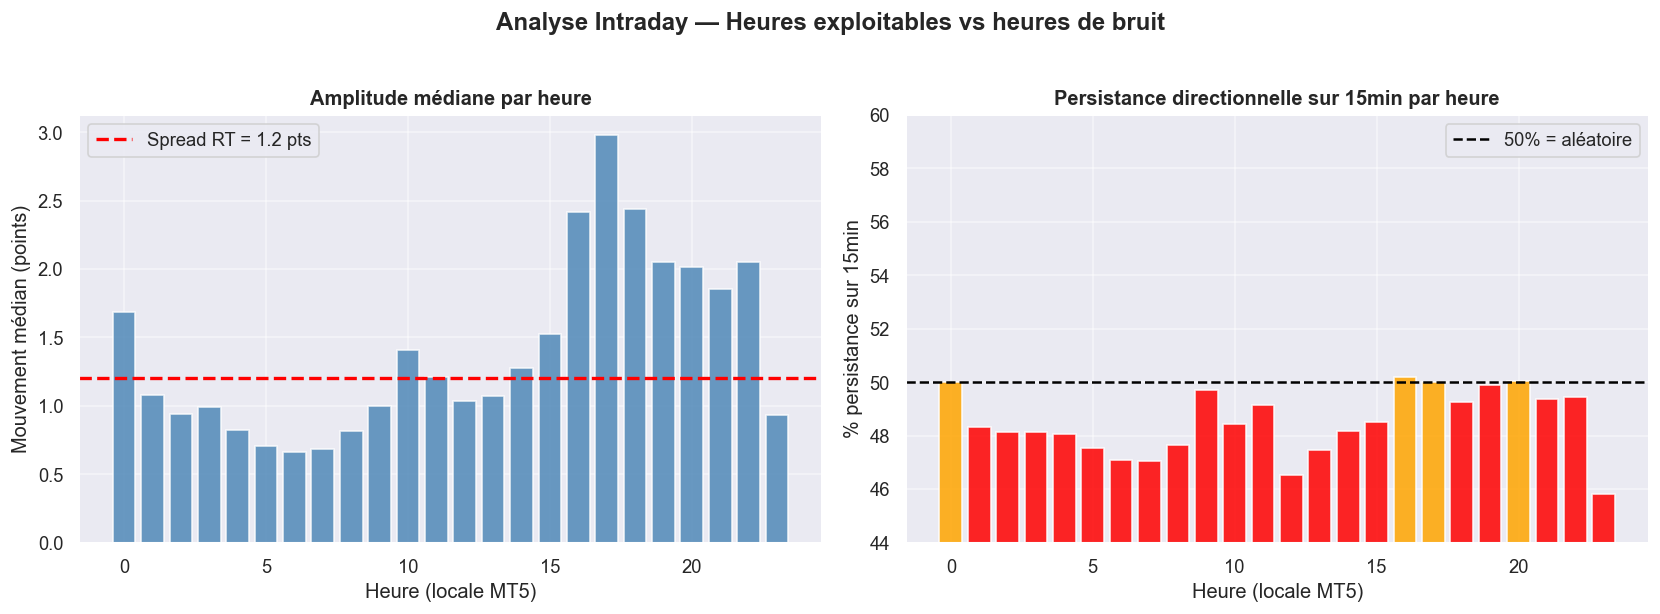


→ VERT = signal > 52% | ORANGE = 50-52% | ROUGE = bruit dominant


In [30]:
# ── 12.5 Analyse par heure de la journée ─────────────────────────────────────
N_HEURE = 3
df_sp['hour']       = df_sp.index.hour
df_sp['log_ret_abs']= df_sp['log_ret'].abs()
df_sp['dir_now']    = np.sign(df_sp['log_ret'])
df_sp['dir_future'] = np.sign(df_sp['close'].shift(-N_HEURE) - df_sp['close'])
df_sp['persiste']   = (df_sp['dir_now'] == df_sp['dir_future']).astype(float)
df_sp.loc[df_sp['dir_now'] == 0, 'persiste'] = np.nan

hourly = df_sp.groupby('hour').agg(
    move_median_ret=('log_ret_abs', 'median'),
    persistance=('persiste', 'mean'),
    n_obs=('close', 'count'),
).reset_index()
hourly['move_median_pts'] = hourly['move_median_ret'] * prix_moyen
hourly['persistance_pct'] = hourly['persistance'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(hourly['hour'], hourly['move_median_pts'], color='steelblue', alpha=0.8, edgecolor='white')
ax.axhline(SPREAD_RT, color='red', lw=2, linestyle='--', label=f'Spread RT = {SPREAD_RT} pts')
ax.set_xlabel('Heure (locale MT5)'); ax.set_ylabel('Mouvement médian (points)')
ax.set_title('Amplitude médiane par heure', fontweight='bold'); ax.legend()

ax = axes[1]
colors_h = ['green' if x > 52 else ('orange' if x >= 50 else 'red') for x in hourly['persistance_pct']]
ax.bar(hourly['hour'], hourly['persistance_pct'], color=colors_h, alpha=0.85, edgecolor='white')
ax.axhline(50, color='black', lw=1.5, linestyle='--', label='50% = aléatoire')
ax.set_xlabel('Heure (locale MT5)'); ax.set_ylabel(f'% persistance sur {N_HEURE*5}min')
ax.set_title(f'Persistance directionnelle sur {N_HEURE*5}min par heure', fontweight='bold')
ax.set_ylim(44, 60); ax.legend()

plt.suptitle('Analyse Intraday — Heures exploitables vs heures de bruit', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print('\n→ VERT = signal > 52% | ORANGE = 50-52% | ROUGE = bruit dominant')

## 13. Calibration de la Labélisation

> Synthèse des analyses de la section 12 pour choisir le label optimal.

In [31]:
# ── 13.1 Score combiné par horizon ───────────────────────────────────────────
df_merge = df_horizons.merge(df_ratios, on=['horizon_bougies', 'horizon_minutes'])
df_merge['score'] = df_merge['persistance_dir'] * 0.5 + df_merge['pct_couvre_spread'] * 0.5

print('=== Classement des horizons (score = persistance + rentabilité) ===')
display(df_merge[['horizon_bougies', 'horizon_minutes', 'persistance_dir',
                   'pct_couvre_spread', 'move_median_pts', 'score']]
        .sort_values('score', ascending=False).reset_index(drop=True))

best   = df_merge.loc[df_merge['score'].idxmax()]
N_BEST = int(best['horizon_bougies'])
print(f"\n  ✅ Meilleur horizon : {N_BEST} bougies ({N_BEST*5} minutes)")
print(f"  Persistance : {best['persistance_dir']:.1f}%  |  Spread couvert : {best['pct_couvre_spread']:.1f}%")

=== Classement des horizons (score = persistance + rentabilité) ===


,horizon_bougies,horizon_minutes,persistance_dir,pct_couvre_spread,move_median_pts,score
0,24,120,49.5,89.5,6.75,69.50
1,18,90,49.5,87.6,5.75,68.55
2,12,60,49.3,84.7,4.61,67.00
3,8,40,49.1,81.0,3.75,65.05
4,6,30,49.1,78.1,3.22,63.60
5,4,20,48.5,73.4,2.50,60.95
6,3,15,48.5,69.7,2.25,59.10
7,2,10,48.3,63.8,1.75,56.05
8,1,5,48.0,52.2,1.25,50.10



  ✅ Meilleur horizon : 24 bougies (120 minutes)
  Persistance : 49.5%  |  Spread couvert : 89.5%


=== Distribution du label final ===
  Horizon   : 24 bougies (120 min)
  Seuil     : 1.2 pts (spread aller-retour Admirals)
  Up   (1)  : 47,996  (53.7% des labellisés)
  Down (0)  : 41,447  (46.3% des labellisés)
  Neutre    : 10,556  (ignorés à l'entraînement)
  Conservation : 89.4%
  Équilibre : ⚠️ Rééquilibrage nécessaire


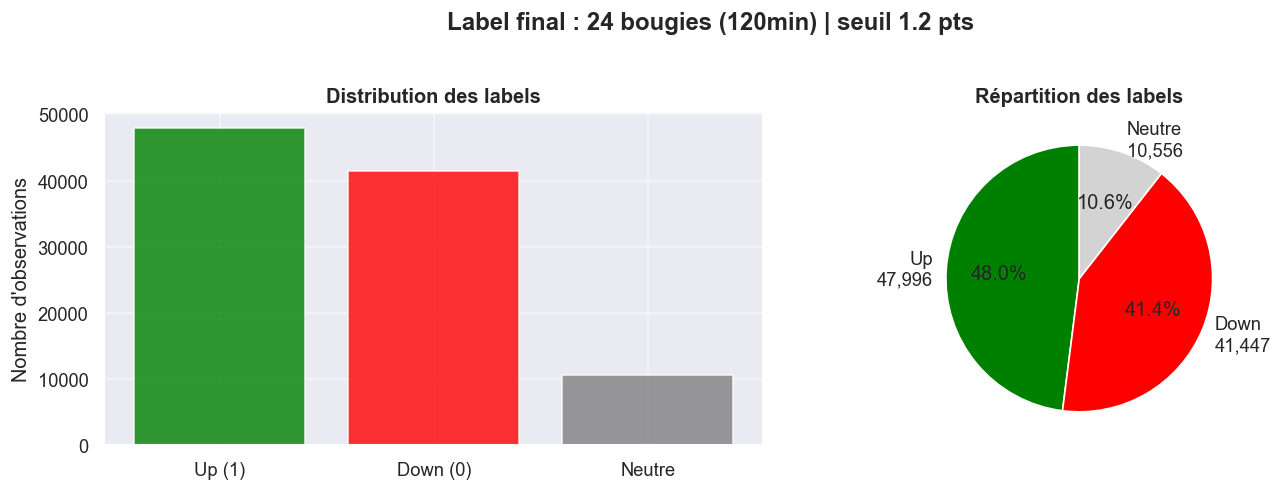


╔═══════════════════════════════════════════════════════╗
║   À COPIER DANS LE NOTEBOOK FEATURE ENGINEERING       ║
╠═══════════════════════════════════════════════════════╣
║                                                       ║
║  N_LABEL   = 24    # horizon optimal en bougies M5  ║
║  SEUIL_PTS = 1.2   # spread aller-retour Admirals  ║
║                                                       ║
║  move = df['close'].shift(-N_LABEL) - df['close']    ║
║  df['label'] = np.where(                             ║
║      move >  SEUIL_PTS,  1,    # UP                  ║
║      np.where(                                        ║
║          move < -SEUIL_PTS, 0, # DOWN                ║
║          np.nan))               # Neutre → ignoré    ║
╚═══════════════════════════════════════════════════════╝



In [32]:
# ── 13.2 Construction et validation du label final ───────────────────────────
# Justification :
# - SEUIL = spread aller-retour → élimine les mouvements non rentables
# - NaN (neutre) = bougie trop petite pour trader → ignorée à l'entraînement
# - N_LABEL = horizon où signal + rentabilité sont maximaux

N_LABEL   = N_BEST
SEUIL_PTS = SPREAD_RT  # 1.20 pts

move = df_sp['close'].shift(-N_LABEL) - df_sp['close']
df_sp['label'] = np.where(move >  SEUIL_PTS,  1,
                 np.where(move < -SEUIL_PTS,  0,
                 np.nan))

n_up   = (df_sp['label'] == 1).sum()
n_down = (df_sp['label'] == 0).sum()
n_neu  = df_sp['label'].isna().sum()
taux   = df_sp['label'].notna().mean() * 100

print('=== Distribution du label final ===')
print(f'  Horizon   : {N_LABEL} bougies ({N_LABEL*5} min)')
print(f'  Seuil     : {SEUIL_PTS} pts (spread aller-retour Admirals)')
print(f'  Up   (1)  : {n_up:,}  ({n_up/(n_up+n_down)*100:.1f}% des labellisés)')
print(f'  Down (0)  : {n_down:,}  ({n_down/(n_up+n_down)*100:.1f}% des labellisés)')
print(f'  Neutre    : {n_neu:,}  (ignorés à l\'entraînement)')
print(f'  Conservation : {taux:.1f}%')
print(f"  Équilibre : {'✅ Bon' if abs(n_up-n_down)/(n_up+n_down) < 0.05 else '⚠️ Rééquilibrage nécessaire'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.bar(['Up (1)', 'Down (0)', 'Neutre'], [n_up, n_down, n_neu],
       color=['green', 'red', 'gray'], alpha=0.8, edgecolor='white')
ax.set_title('Distribution des labels', fontweight='bold'); ax.set_ylabel("Nombre d'observations")

ax = axes[1]
ax.pie([n_up, n_down, n_neu],
       labels=[f'Up\n{n_up:,}', f'Down\n{n_down:,}', f'Neutre\n{n_neu:,}'],
       colors=['green', 'red', 'lightgray'], autopct='%1.1f%%', startangle=90)
ax.set_title('Répartition des labels', fontweight='bold')

plt.suptitle(f'Label final : {N_LABEL} bougies ({N_LABEL*5}min) | seuil {SEUIL_PTS} pts',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print(f"""
╔═══════════════════════════════════════════════════════╗
║   À COPIER DANS LE NOTEBOOK FEATURE ENGINEERING       ║
╠═══════════════════════════════════════════════════════╣
║                                                       ║
║  N_LABEL   = {N_LABEL:<3}   # horizon optimal en bougies M5  ║
║  SEUIL_PTS = {SEUIL_PTS:<4}  # spread aller-retour Admirals  ║
║                                                       ║
║  move = df['close'].shift(-N_LABEL) - df['close']    ║
║  df['label'] = np.where(                             ║
║      move >  SEUIL_PTS,  1,    # UP                  ║
║      np.where(                                        ║
║          move < -SEUIL_PTS, 0, # DOWN                ║
║          np.nan))               # Neutre → ignoré    ║
╚═══════════════════════════════════════════════════════╝
""")

## 14. Tableau de synthèse & Conclusions

In [33]:
synthese_rows = []
for name in df_returns.columns:
    r = df_returns[name].dropna()
    jb, jb_p = jarque_bera(r)
    adf_s, adf_p, _ = adf_test(r)
    _, lb_p  = ljung_box(r,    20)
    _, lb2_p = ljung_box(r**2, 20)
    var95    = r.quantile(0.05)
    cvar95   = r[r <= var95].mean()
    synthese_rows.append({
        'Actif': name, 'N bougies': len(r),
        'Std': round(r.std(), 6), 'Skewness': round(r.skew(), 4),
        'Kurtosis exc.': round(r.kurtosis(), 4),
        'Vol. Ann. (%)': round(r.std() * np.sqrt(BOUGIES_PAR_AN) * 100, 2),
        'Normale ?': '❌ Non' if jb_p < 0.05 else '✅ Oui',
        'Stationnaire ?': '✅ Oui' if adf_p < 0.05 else '❌ Non',
        'Effet ARCH ?': '✅ Oui' if lb2_p < 0.05 else '❌ Non',
        'VaR 95%': round(var95, 6), 'CVaR 95%': round(cvar95, 6),
    })
display(pd.DataFrame(synthese_rows).set_index('Actif').T)

Actif,SP500,GOLD,BRENT,EURUSD
N bougies,87990,87990,87990,87990
Std,0.000716,0.00091,0.001789,0.000307
Skewness,0.1884,-0.8237,2.5342,0.4252
Kurtosis exc.,385.5714,48.4013,1447.12,51.7327
Vol. Ann. (%),10.03,12.75,25.08,4.31
Normale ?,❌ Non,❌ Non,❌ Non,❌ Non
Stationnaire ?,✅ Oui,✅ Oui,✅ Oui,✅ Oui
Effet ARCH ?,✅ Oui,✅ Oui,✅ Oui,✅ Oui
VaR 95%,-0.000858,-0.001186,-0.001856,-0.000433
CVaR 95%,-0.001607,-0.002178,-0.003602,-0.000688


## Conclusions

| Propriété | Résultat | Implication pour la modélisation |
|---|---|---|
| **Non-normalité** | Kurtosis élevée, queues épaisses | Modèles gaussiens inadaptés |
| **Stationnarité** | Prix non-stat., rendements stat. | Travailler en log returns |
| **Autocorrélation** | Faible sur ret., forte sur ret.² | Effets ARCH présents |
| **Corrélations** | Instables dans le temps | Corrélations statiques trompeuses |
| **Runs M5** | Médiane 1-2 bougies dominant | Label sur N bougies + seuil spread |
| **Label calibré** | Horizon optimal + seuil 1.20 pts | Bruit non exploitable filtré |

**Références** : Fama (1965), Mandelbrot (1963), Dingli & Sant Fournier (2017).